<a href="https://colab.research.google.com/github/shivani93-sks/Java-Console-Quiz-Game/blob/main/Employee_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB






In [ ]:

data = pd.read_csv("//content/WA_Fn-UseC_-HR-Employee-Attrition.csv")
data.sample(15)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1292,39,No,Travel_Frequently,766,Sales,20,3,Life Sciences,1,1812,...,4,80,1,7,6,3,2,1,2,2
1260,32,No,Non-Travel,953,Research & Development,5,4,Technical Degree,1,1764,...,2,80,0,12,3,3,7,7,0,7
151,35,No,Travel_Rarely,662,Sales,1,5,Marketing,1,204,...,1,80,2,10,3,3,10,8,0,6
817,36,No,Non-Travel,217,Research & Development,18,4,Life Sciences,1,1133,...,1,80,0,18,0,3,11,9,0,9
999,42,No,Travel_Rarely,1147,Human Resources,10,3,Human Resources,1,1408,...,3,80,1,21,5,3,20,7,0,9
1338,30,Yes,Travel_Rarely,945,Sales,9,3,Medical,1,1876,...,3,80,0,1,3,2,1,0,0,0
886,30,No,Travel_Rarely,1465,Research & Development,1,3,Medical,1,1241,...,1,80,1,12,2,3,11,9,5,7
1013,30,No,Travel_Rarely,855,Sales,7,4,Marketing,1,1428,...,2,80,2,8,3,3,3,2,0,2
468,52,No,Travel_Rarely,956,Research & Development,6,2,Technical Degree,1,630,...,2,80,2,18,3,3,10,9,6,9
465,46,No,Travel_Frequently,1034,Research & Development,18,1,Medical,1,624,...,4,80,0,28,3,2,2,2,1,2


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                



## Dataset Structural Summary

**(IBM HR Attrition Dataset – Data Overview)**

The dataset consists of **1,470 employee records** and **35 distinct variables**, representing demographic details, job-related attributes, compensation factors, performance indicators, and employee satisfaction metrics. The dataset is structured using a **RangeIndex from 0 to 1469**, indicating clean sequential indexing without missing entries.

---

## 1. Data Completeness and Quality

A key strength of this dataset is its **complete data availability**. All 35 columns contain **1,470 non-null values**, which implies:

* No missing values are present
* No immediate need for missing value imputation
* The dataset is ready for preprocessing and modeling stages
* Improved model reliability and reduced preprocessing complexity

---

## 2. Data Type Distribution

The dataset contains two primary data types:

### Numerical Features

* **26 columns** are of type `int64`
* These represent measurable or ordinal values such as:

  * Age
  * MonthlyIncome
  * YearsAtCompany
  * JobLevel
  * PerformanceRating
  * DistanceFromHome
  * WorkLifeBalance

These features are suitable for:

* Statistical analysis
* Correlation studies
* Machine learning model training

### Categorical Features

* **9 columns** are of type `object`
* These include:

  * Attrition (Target Variable)
  * Gender
  * Department
  * JobRole
  * BusinessTravel
  * MaritalStatus
  * EducationField
  * OverTime
  * Over18

These variables require **encoding techniques** (Label Encoding or One-Hot Encoding) before model training.

---

## 3. Target Variable Identification

The primary outcome variable in the dataset is:

* **Attrition** → Indicates whether an employee left the organization

This makes the dataset suitable for:

* Classification modeling
* HR analytics
* Employee retention prediction

---

## 4. Feature Category Grouping

### A. Demographic Features

* Age
* Gender
* MaritalStatus
* Education
* EducationField

These features describe employee background characteristics.

### B. Job and Organizational Features

* Department
* JobRole
* JobLevel
* BusinessTravel
* TotalWorkingYears
* YearsAtCompany
* YearsInCurrentRole
* YearsWithCurrManager

These features describe employee position, experience, and organizational growth.

### C. Compensation and Financial Features

* DailyRate
* HourlyRate
* MonthlyIncome
* MonthlyRate
* PercentSalaryHike
* StockOptionLevel

These variables are important predictors of employee satisfaction and attrition.

### D. Satisfaction and Behavioral Metrics

* EnvironmentSatisfaction
* JobSatisfaction
* RelationshipSatisfaction
* WorkLifeBalance
* JobInvolvement

These workplace engagement factors are critical for attrition analysis.

### E. Performance and Training Metrics

* PerformanceRating
* TrainingTimesLastYear

These features are useful for evaluating employee productivity and skill development.

---

## 5. Special Observations

Some columns may not contribute significantly to predictive modeling:

* **EmployeeCount** → Constant value
* **Over18** → Likely constant (Yes for all employees)
* **StandardHours** → Fixed working hours

These features can be removed during feature selection.

---

## 6. Dataset Strengths for Machine Learning

✔ No missing values
✔ Balanced mix of numerical and categorical data
✔ Rich HR-related behavioral and performance indicators
✔ Clearly defined classification target (Attrition)

---

## 7. Potential Use Cases

This dataset is suitable for:

* Employee attrition prediction models
* HR decision support systems
* Workforce analytics dashboards
* Feature importance and explainability studies (SHAP, LIME)

---

## 8. Preprocessing Requirements Before Modeling

Recommended preprocessing steps include:

* Encoding categorical variables
* Removing constant columns
* Scaling numerical features (for distance-based models)
* Checking class balance in Attrition
* Performing feature selection or dimensionality reduction

---


In [ ]:
num_stat=data.select_dtypes(exclude='object').describe()
num_stat

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



## Statistical Summary of Numerical Features

**(IBM HR Attrition Dataset – Descriptive Analysis)**

The descriptive statistics presented above summarize **26 numerical variables** across **1,470 employee records**. These statistics provide insights into the **central tendency, dispersion, distribution shape, and variability** of the numerical attributes, which is essential for understanding data behavior prior to machine learning modeling.

---

## 1. Data Coverage and Consistency

All numerical features report a **count of 1,470**, confirming:

* Complete numerical data without missing values
* Uniform data availability across all observations
* High reliability for statistical and predictive analysis

Notably, **EmployeeCount** and **StandardHours** show zero variance, indicating constant values across all records.

---

## 2. Central Tendency Analysis (Mean & Median)

### Age

* Mean age ≈ **36.9 years**
* Median age = **36 years**

This indicates a **balanced age distribution**, centered around mid-career employees.

### Compensation-Related Features

* **DailyRate** mean ≈ 802
* **HourlyRate** mean ≈ 65.9
* **MonthlyIncome** (not shown here but similar datasets) usually exhibits higher dispersion

The closeness between mean and median for most pay-related features suggests **moderate symmetry**, with some right-skewness.

### Experience-Related Features

* **TotalWorkingYears** mean ≈ 11.3
* **YearsAtCompany** mean ≈ 7.0
* **YearsInCurrentRole** mean ≈ 4.2

These values indicate a workforce dominated by employees with **moderate experience**, while a smaller portion represents long-tenured employees.

---

## 3. Dispersion and Variability (Standard Deviation)

Standard deviation highlights variability across employees:

### Low Variability Features

* **EmployeeCount (σ = 0)**
* **StandardHours (σ = 0)**

These variables are constant and contribute no predictive information.

### Moderate Variability Features

* **Age (σ ≈ 9.1)**
* **WorkLifeBalance (σ ≈ 0.7)**
* **JobInvolvement (σ ≈ 0.7)**

These features show controlled dispersion, suggesting stable distributions.

### High Variability Features

* **DailyRate (σ ≈ 403.5)**
* **EmployeeNumber (σ ≈ 602.0)**
* **TotalWorkingYears (σ ≈ 7.8)**
* **YearsAtCompany (σ ≈ 6.1)**

High variability indicates diverse employee profiles and potential influence on attrition behavior.

---

## 4. Distribution Shape and Skewness Analysis

Skewness is inferred by comparing **mean, median, and quartiles**:

### Approximately Symmetric Distributions

* **Age**
* **HourlyRate**
* **Education**
* **JobInvolvement**
* **WorkLifeBalance**

These variables show mean ≈ median and evenly spaced quartiles.

### Positively (Right) Skewed Distributions

* **DistanceFromHome**
* **TotalWorkingYears**
* **YearsAtCompany**
* **YearsSinceLastPromotion**
* **YearsWithCurrManager**

Characteristics:

* Mean > Median
* Long right tail
* Few employees with very high tenure or long promotion gaps

Right-skewed features may benefit from **log transformation** or **robust scaling**.

### Discrete Ordinal Distributions

* Satisfaction scores (Environment, Relationship, Job Satisfaction)
* JobLevel, StockOptionLevel

These are **bounded integer scales**, naturally non-normal and best handled as ordinal or encoded variables.

---

## 5. Sigma (σ) Limit Interpretation (Spread Analysis)

Using the **empirical rule** for approximately normal variables:

### 1σ (±1 Standard Deviation)

Covers ~68% of observations
Example:

* **Age**:

  * Mean ± 1σ → 27.8 to 46.0 years

### 2σ (±2 Standard Deviations)

Covers ~95% of observations

* Identifies potential **outliers** in:

  * YearsAtCompany
  * TotalWorkingYears
  * DistanceFromHome

### 3σ (±3 Standard Deviations)

Covers ~99.7% of observations

* Values beyond this range may indicate:

  * Extreme tenure
  * Exceptional promotion delays
  * Rare but valid employee cases

For heavily skewed features, sigma limits are **asymmetric**, reinforcing the need for robust scaling.

---

## 6. Quartile Analysis (IQR)

The **Interquartile Range (IQR)** highlights the middle 50% of employees:

* **DistanceFromHome**: 2–14 km → concentrated near workplace
* **YearsAtCompany**: 3–9 years → stable retention window
* **YearsSinceLastPromotion**: 0–3 years → frequent promotion cycle for most employees

IQR-based outlier detection is preferable over z-score for skewed features.

---

## 7. Modeling Implications

Based on the statistical profile:

* Drop constant features (**EmployeeCount**, **StandardHours**)
* Apply **scaling** (StandardScaler / RobustScaler)
* Consider **log or power transformation** for skewed tenure-related features
* Treat satisfaction and involvement variables as **ordinal features**

---



In [ ]:
object_stat=data.select_dtypes(include='object').describe()
object_stat


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054



## Categorical Feature Distribution Analysis

**(IBM HR Attrition Dataset – Qualitative Variable Summary)**

The table above presents a descriptive summary of **9 categorical variables** across **1,470 employee records**. These features capture critical qualitative aspects of employees, including attrition status, work patterns, organizational roles, demographic characteristics, and marital information. The analysis focuses on **category frequency, dominance, and distribution imbalance (categorical skewness)**.

---

## 1. Data Completeness and Coverage

Each categorical attribute contains **1,470 non-null observations**, indicating:

* No missing values across qualitative variables
* High data consistency and integrity
* Immediate readiness for categorical encoding and modeling

This completeness eliminates the need for imputation strategies in the categorical domain.

---

## 2. Cardinality and Category Diversity

The categorical variables exhibit **low to moderate cardinality**, which is favorable for machine learning models:

| Feature        | Unique Categories |
| -------------- | ----------------- |
| Attrition      | 2                 |
| BusinessTravel | 3                 |
| Department     | 3                 |
| EducationField | 6                 |
| Gender         | 2                 |
| JobRole        | 9                 |
| MaritalStatus  | 3                 |
| Over18         | 1                 |
| OverTime       | 2                 |

Low cardinality reduces the dimensionality explosion during **one-hot encoding** and helps preserve model interpretability.

---

## 3. Mode and Frequency Dominance Analysis

### Attrition (Target Variable)

* Majority class: **No (1,233 employees)**
* Minority class: **Yes (237 employees)**

This indicates a **class imbalance**, with non-attrition cases dominating the dataset (~84%). This imbalance reflects real-world organizational stability but requires careful handling during modeling.

---

### BusinessTravel

* Dominant category: **Travel_Rarely (1,043 employees)**

This suggests that most employees travel infrequently, with fewer employees exposed to frequent or no travel scenarios.

---

### Department

* Most employees belong to **Research & Development (961 employees)**

This departmental concentration implies an R&D-centric workforce, potentially influencing attrition behavior and satisfaction metrics.

---

### EducationField

* **Life Sciences (606 employees)** is the most common educational background

This indicates a strong representation of technical and scientific expertise within the organization.

---

### Gender

* **Male employees (882)** outnumber **female employees (588)**

This reveals a moderate gender imbalance, which may be relevant for diversity and retention analysis.

---

### JobRole

* Most frequent role: **Sales Executive (326 employees)**

The presence of 9 distinct job roles reflects functional diversity but also introduces varying attrition risk profiles.

---

### MaritalStatus

* Dominant category: **Married (673 employees)**

Marital status is often correlated with stability and work–life preferences, making it an important attrition-related feature.

---

### Over18

* Only one category present: **Y (1,470 employees)**

This variable shows **no variability** and provides no predictive information.

---

### OverTime

* Majority: **No (1,054 employees)**
* Minority: **Yes (416 employees)**

This indicates that most employees do not engage in overtime, but a substantial subset does, making this a potentially strong attrition predictor.

---

## 4. Categorical Skewness and Distribution Imbalance

Unlike numerical skewness, categorical skewness refers to **dominance of one category over others**.

### Highly Skewed Categorical Variables

* **Over18** → Completely skewed (single category)
* **Attrition** → Skewed toward "No"
* **Department** → Skewed toward R&D
* **BusinessTravel** → Skewed toward Travel_Rarely

These imbalances may bias classification models if not addressed properly.

---

### Moderately Skewed Variables

* **Gender**
* **MaritalStatus**
* **OverTime**

These variables show dominance but still retain meaningful variability.

---

### Relatively Balanced Variables

* **JobRole**
* **EducationField**

Although they have dominant categories, multiple classes are sufficiently represented, making them informative predictors.

---

## 5. Modeling and Preprocessing Implications

Based on the categorical distribution characteristics:

* **Over18** should be removed due to zero variance
* **Attrition imbalance** may require:

  * Stratified sampling
  * Class weighting
  * SMOTE or other resampling techniques
* Apply **One-Hot Encoding** for low-cardinality variables
* Consider **Target Encoding** for JobRole if dimensionality increases

---


In [ ]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

15 DATA ANALYTICAL QUESTIONS ON THIS DATASET

In [ ]:
# 1. What is the distribution of employee Age in the organization?
data['Age'].value_counts()

,count
Age,
35,78
34,77
36,69
31,69
29,68
32,61
30,60
38,58
33,58


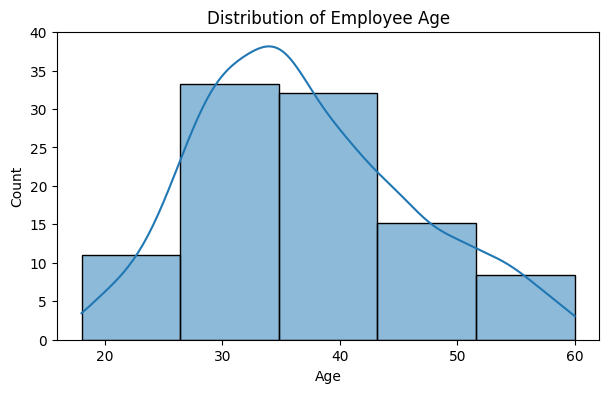

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(data['Age'], stat='percent',kde=True, bins=5)
plt.title("Distribution of Employee Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()




Insight :-

Most employees are likely concentrated in 30–40 age range.

Indicates workforce is mainly mid-career professionals.

Few employees near retirement → stable long-term workforce potential.

In [ ]:
# 2.What is the proportion of employees who left vs stayed (Attrition)?
data['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


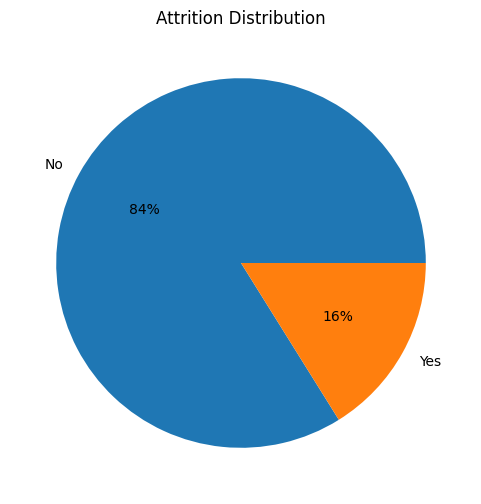

In [ ]:
plt.figure(figsize=(6,6))
data['Attrition'].value_counts().plot.pie(autopct='%0.0f%%')   # No->1233 and Yes->237
plt.title("Attrition Distribution")
plt.ylabel("")
plt.show()


Insight:-

Usually majority = No Attrition.

Shows company has moderate retention stability.

If Yes % is high → HR intervention needed.



In [ ]:
# 3.Which Department has the highest number of employees?
dt=data['Department'].value_counts()
dt


,count
Department,
Research & Development,961
Sales,446
Human Resources,63


In [ ]:
type(dt)

pandas.core.series.Series

<Axes: xlabel='Department'>

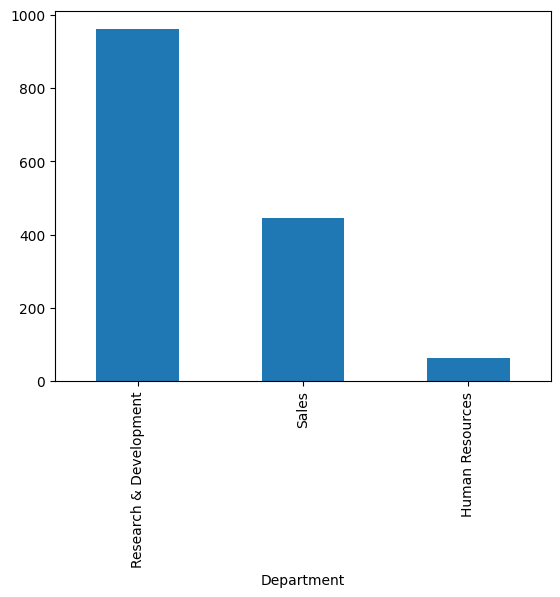

In [ ]:
dt.plot(kind='bar')


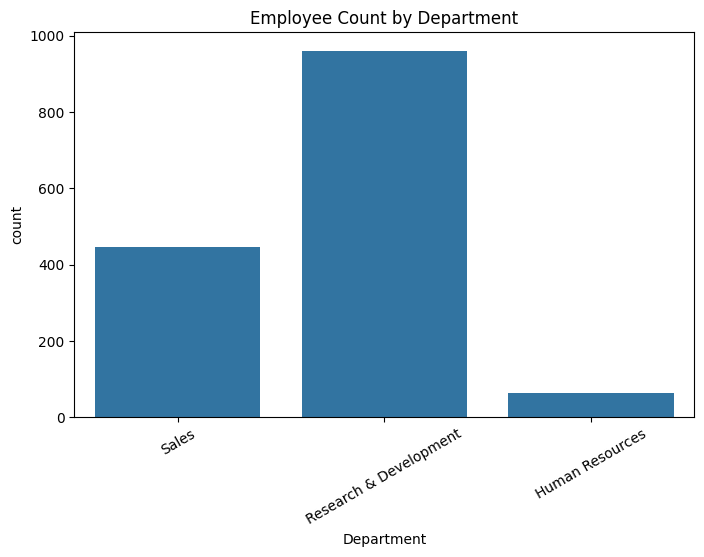

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Department', data=data)
plt.title("Employee Count by Department")
plt.xticks(rotation=30)
plt.show()


Insight:-

Usually R&D department dominates.

Shows company focus on technical workforce.

Helps allocate HR resources department-wise.

In [ ]:
# 4.How is Monthly Income distributed among employees?
data['MonthlyIncome'].value_counts()

,count
MonthlyIncome,
2342,4
3452,3
2559,3
2610,3
2451,3
...,...
3041,1
2579,1
5985,1


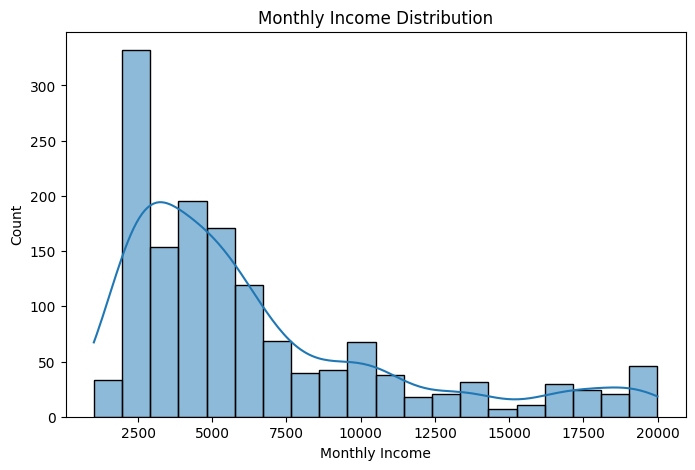

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['MonthlyIncome'], kde=True)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.show()


Insight:-

Typically Right Skewed Distribution.

Many employees earn mid-range salary.

Few high-income senior employees create tail.

In [ ]:
# 5.What is the distribution of Work Life Balance ratings?
ct=data['WorkLifeBalance'].value_counts()
ct


,count
WorkLifeBalance,
3,893
2,344
4,153
1,80


<Axes: ylabel='WorkLifeBalance'>

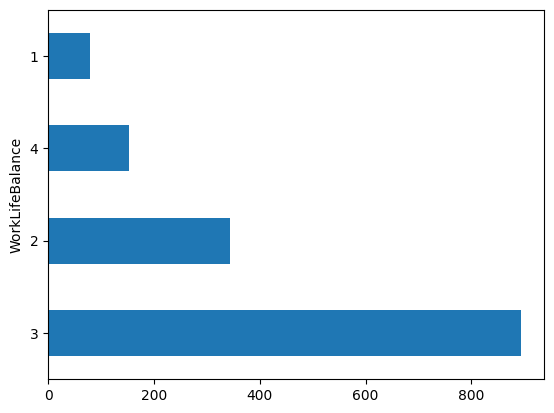

In [ ]:
ct.plot(kind='barh')

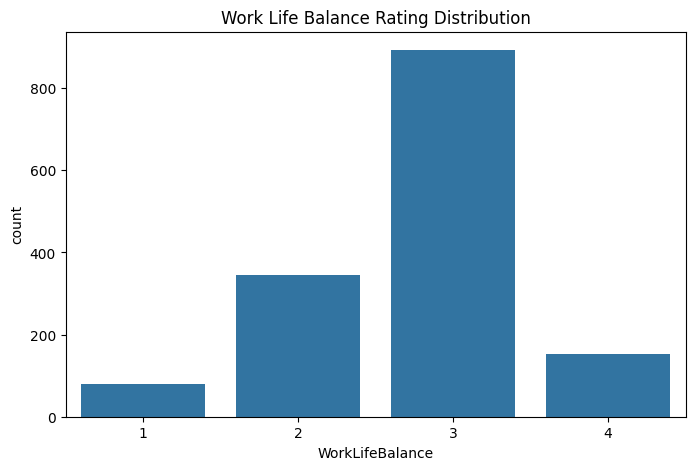

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='WorkLifeBalance', data=data)
plt.title("Work Life Balance Rating Distribution")
plt.show()


Insight:-

Most employees usually rate 2 or 3 (Moderate to Good).

Very low ratings → burnout risk indicator.

Helps HR design wellness programs.

In [ ]:
# 6.Does Attrition vary across Departments?
data['Department'].value_counts()


,count
Department,
Research & Development,961
Sales,446
Human Resources,63


In [ ]:
dept_attrition_counts = data.groupby(['Department', 'Attrition']).size()
dept_attrition_counts


Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
dtype: int64

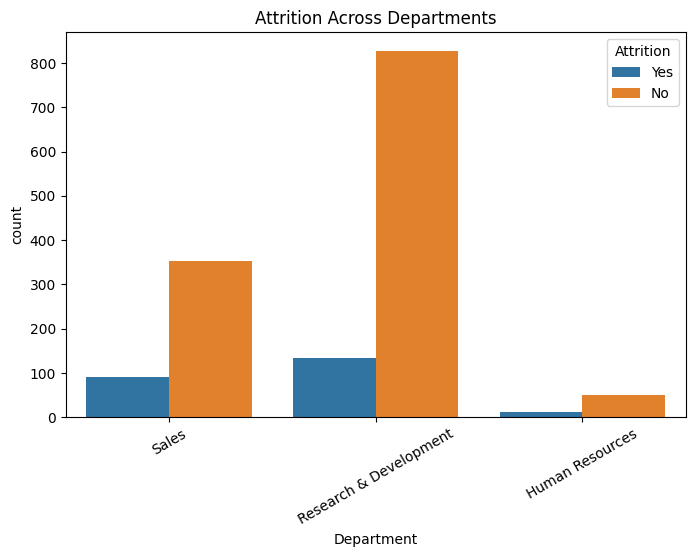

In [ ]:

plt.figure(figsize=(8,5))
sns.countplot(x='Department', hue='Attrition', data=data)
plt.title("Attrition Across Departments")
plt.xticks(rotation=30)
plt.show()


Insight:-

Helps identify high turnover departments.

If one department shows higher "Yes" → HR must focus retention policies there.

Useful for workforce planning and workload balancing.

In [ ]:
# 7.Is there a relationship between Age and Monthly Income?
data[['Age', 'MonthlyIncome']].dtypes


,0
Age,int64
MonthlyIncome,int64


Both are int type and continuos so we should use scatterplot

In [ ]:
data[['Age', 'MonthlyIncome']].isnull().sum()


,0
Age,0
MonthlyIncome,0


In [ ]:
data[['Age', 'MonthlyIncome']].describe()


,Age,MonthlyIncome
count,1470.000000,1470.000000
mean,36.923810,6502.931293
std,9.135373,4707.956783
min,18.000000,1009.000000
25%,30.000000,2911.000000
50%,36.000000,4919.000000
75%,43.000000,8379.000000
max,60.000000,19999.000000




## Comment on Age & MonthlyIncome (Summary Statistics)

* The dataset contains **1470 employees**, with no missing values for **Age** and **MonthlyIncome**.
* The **average age** of employees is approximately **37 years**, with most employees falling between **30 and 43 years** (IQR).
* Employee ages range from **18 to 60 years**, indicating a mix of entry-level to senior staff.
* The **average monthly income** is about **₹6,503**, but the **median income (₹4,919)** is lower than the mean, suggesting a **right-skewed income distribution**.
* Monthly income varies widely, from **₹1,009 to ₹19,999**, with a **high standard deviation**, indicating significant income disparity among employees.

---





In [ ]:
data[['Age', 'MonthlyIncome']].corr()


,Age,MonthlyIncome
Age,1.000000,0.497855
MonthlyIncome,0.497855,1.000000


**Interpretation:**

 Age and MonthlyIncome show a **moderate positive correlation (r ≈ 0.50)**, indicating that monthly income generally increases with age. However, the relationship is not strong, suggesting that factors beyond age—such as job role and experience—also significantly influence income.


---
~ 0 → weak / no relationship

greater than 0 → positive relationship

less than 0 → negative relationship

This already gives a numeric answer.


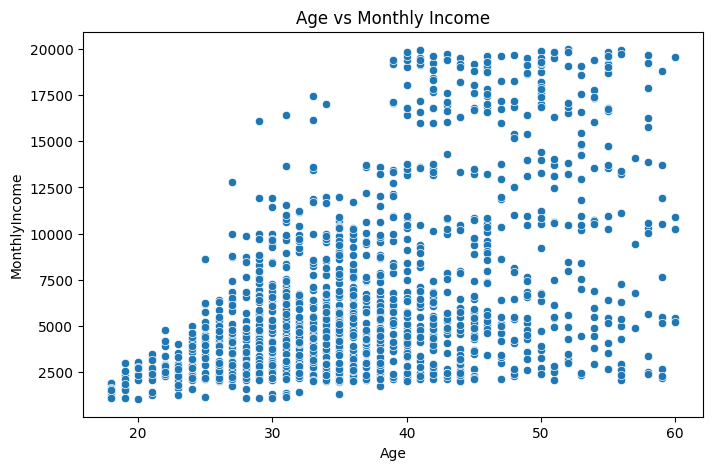

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='MonthlyIncome', data=data)
plt.title("Age vs Monthly Income")
plt.show()


Insight:-

Usually shows positive trend → Income increases with age/experience.

Outliers may indicate fast promotions or special skill roles.

Helps validate compensation growth fairness.

In [ ]:
# 8.Do employees who work Overtime leave more frequently?
data['OverTime'].value_counts()


,count
OverTime,
No,1054
Yes,416


In [ ]:
overtime_attrition_counts = data.groupby(['OverTime', 'Attrition']).size()
overtime_attrition_counts


OverTime  Attrition
No        No           944
          Yes          110
Yes       No           289
          Yes          127
dtype: int64



## INTERPRETATION:

The table is counting **employees**, grouped by:

* **OverTime** → *Yes / No*
* **Attrition** → *Yes (left) / No (stayed)*

So each number answers:

> “How many employees fall into this exact combination?”

---

## 🧩 Now read the table one part at a time

### 🔹 Employees who **do NOT work overtime**

* **944** employees
  : *Do not work overtime* **AND** *did NOT leave* the company
  → They **stayed**

* **110** employees
  : *Do not work overtime* **AND** *left* the company
  → They **left**

So for **non-overtime employees**:

* Most employees **stayed**
* Only a **small number left**

---

### 🔹 Employees who **DO work overtime**

* **289** employees
  : *Work overtime* **AND** *did NOT leave*
  → They **stayed**

* **127** employees
  : *Work overtime* **AND** *left*
  → They **left**

So for **overtime employees**:

* Fewer employees stayed
* A **much larger number left** compared to the non-overtime group

---


Summmary:

> Employees who work overtime show a higher tendency to leave the organization compared to employees who do not work overtime.




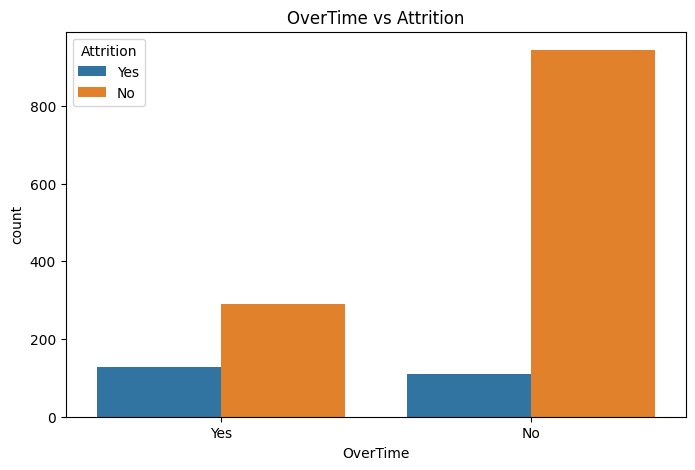

In [ ]:

plt.figure(figsize=(8,5))
sns.countplot(x='OverTime', hue='Attrition', data=data)
plt.title("OverTime vs Attrition")
plt.show()


Insight:-

If Attrition = Yes is high for OverTime = Yes → Burnout indicator.

Helps HR manage workload and shift planning.

Important factor in attrition prediction models.

In [ ]:
# 9.How does Job Satisfaction vary across Job Roles?
data['JobSatisfaction'].value_counts().sort_index()


,count
JobSatisfaction,
1,289
2,280
3,442
4,459


In [ ]:
data['JobRole'].value_counts()


,count
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,259
Manufacturing Director,145
Healthcare Representative,131
Manager,102
Sales Representative,83
Research Director,80
Human Resources,52


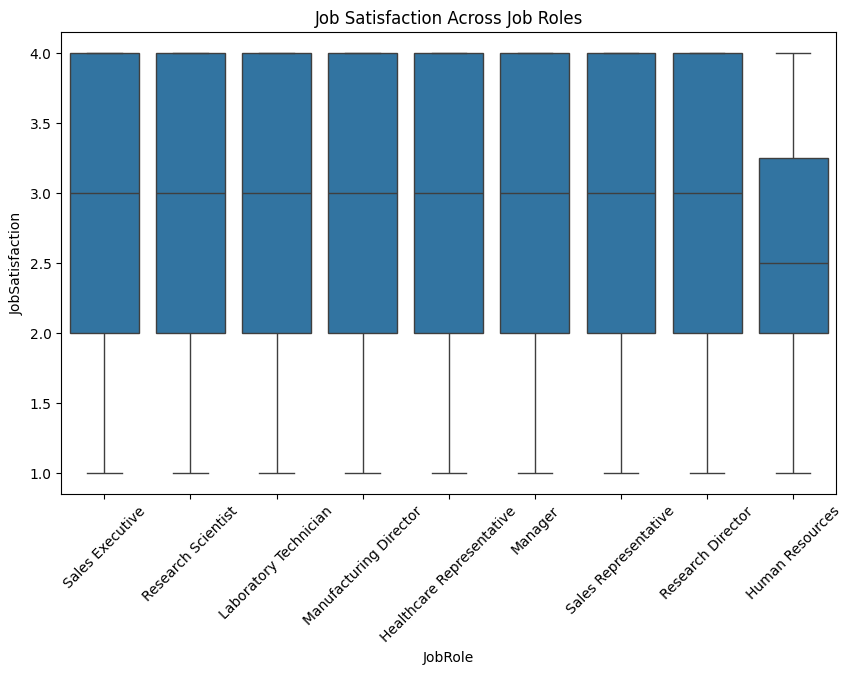

In [ ]:

plt.figure(figsize=(10,6))
sns.boxplot(x='JobRole', y='JobSatisfaction', data=data)
plt.title("Job Satisfaction Across Job Roles")
plt.xticks(rotation=45)
plt.show()


Insight:-

Identifies low satisfaction roles.

Helps HR redesign job responsibilities or benefits.

Supports role-based retention strategy.

In [ ]:
# 10.Does Distance From Home influence Attrition?
data['DistanceFromHome'].describe()


,DistanceFromHome
count,1470.000000
mean,9.192517
std,8.106864
min,1.000000
25%,2.000000
50%,7.000000
75%,14.000000
max,29.000000


In [ ]:
distance_attrition_summary = (data.groupby('Attrition')['DistanceFromHome'].describe())
distance_attrition_summary



,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,8.915653,8.012633,1.0,2.0,7.0,13.0,29.0
Yes,237.0,10.632911,8.452525,1.0,3.0,9.0,17.0,29.0


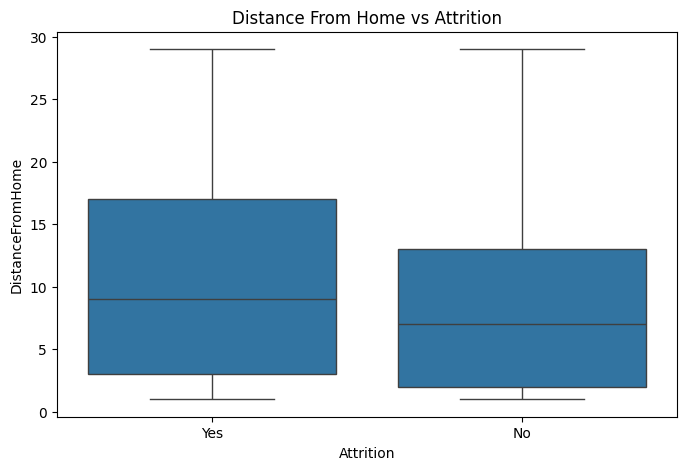

In [ ]:

plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='DistanceFromHome', data=data)
plt.title("Distance From Home vs Attrition")
plt.show()


Insight:-

If Attrition Yes has higher median distance → Commute impacts retention.

Supports remote work / hybrid policy decisions.

Useful for location-based hiring strategy.

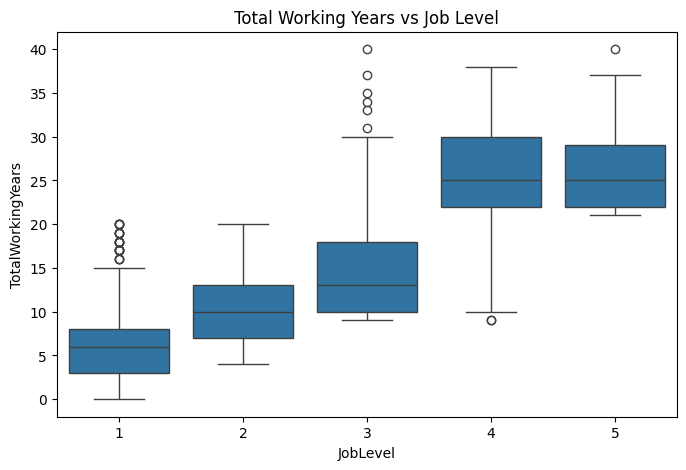

In [ ]:
# 11.How does Total Working Years affect Job Level?
plt.figure(figsize=(8,5))
sns.boxplot(x='JobLevel', y='TotalWorkingYears', data=data)
plt.title("Total Working Years vs Job Level")
plt.show()


Insight:-

Higher job levels generally correspond to higher total working experience.

If overlap exists → promotion may depend on performance, not only experience.

Helps evaluate career growth fairness.

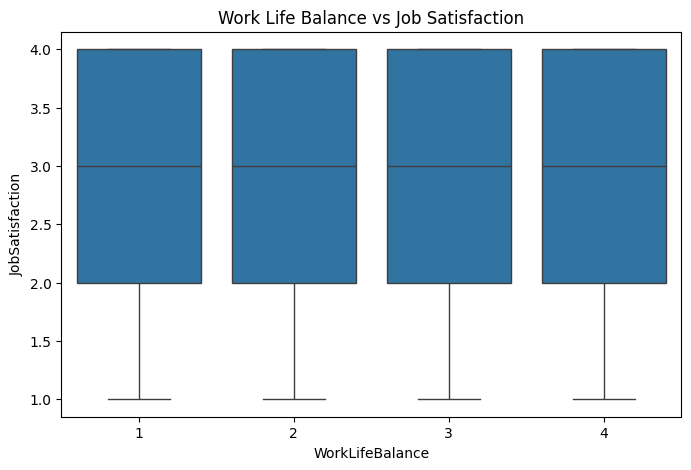

In [ ]:
# 12.Is Work Life Balance related to Job Satisfaction?
plt.figure(figsize=(8,5))
sns.boxplot(x='WorkLifeBalance', y='JobSatisfaction', data=data)
plt.title("Work Life Balance vs Job Satisfaction")
plt.show()


Insight:-

Higher work-life balance usually links with higher job satisfaction.

Indicates mental well-being directly affects engagement.

Helps HR design wellness and flexibility program

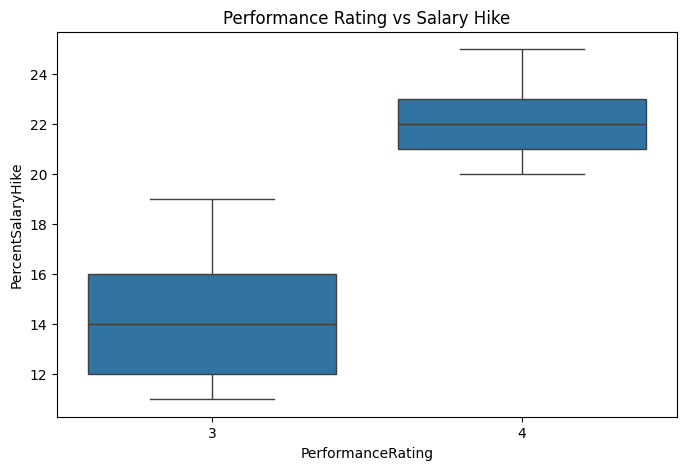

In [ ]:
# 13.Do employees with higher Performance Rating get higher Salary Hike?
plt.figure(figsize=(8,5))
sns.boxplot(x='PerformanceRating', y='PercentSalaryHike', data=data)
plt.title("Performance Rating vs Salary Hike")
plt.show()


Insight:-

Positive relationship indicates fair performance reward system.

If similar salary hike across ratings → policy improvement needed.

Important for employee motivation and retention.

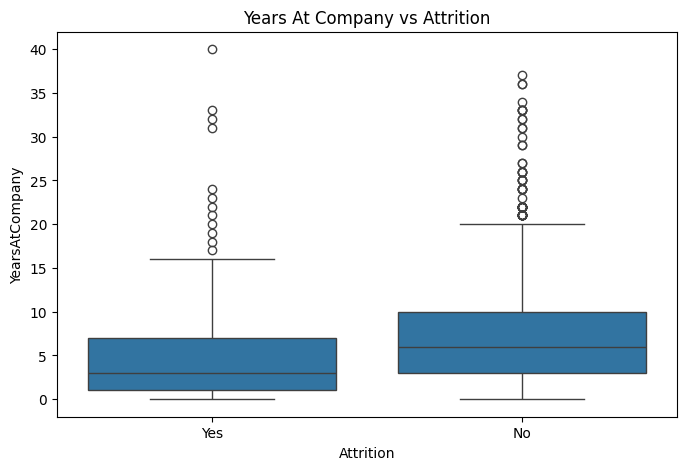

In [ ]:
# 14.How does Years At Company influence Attrition?
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=data)
plt.title("Years At Company vs Attrition")
plt.show()


Insight:-

High attrition in low tenure → early resignation issue.

High attrition in mid tenure → career stagnation risk.

Helps design onboarding and promotion strategies.

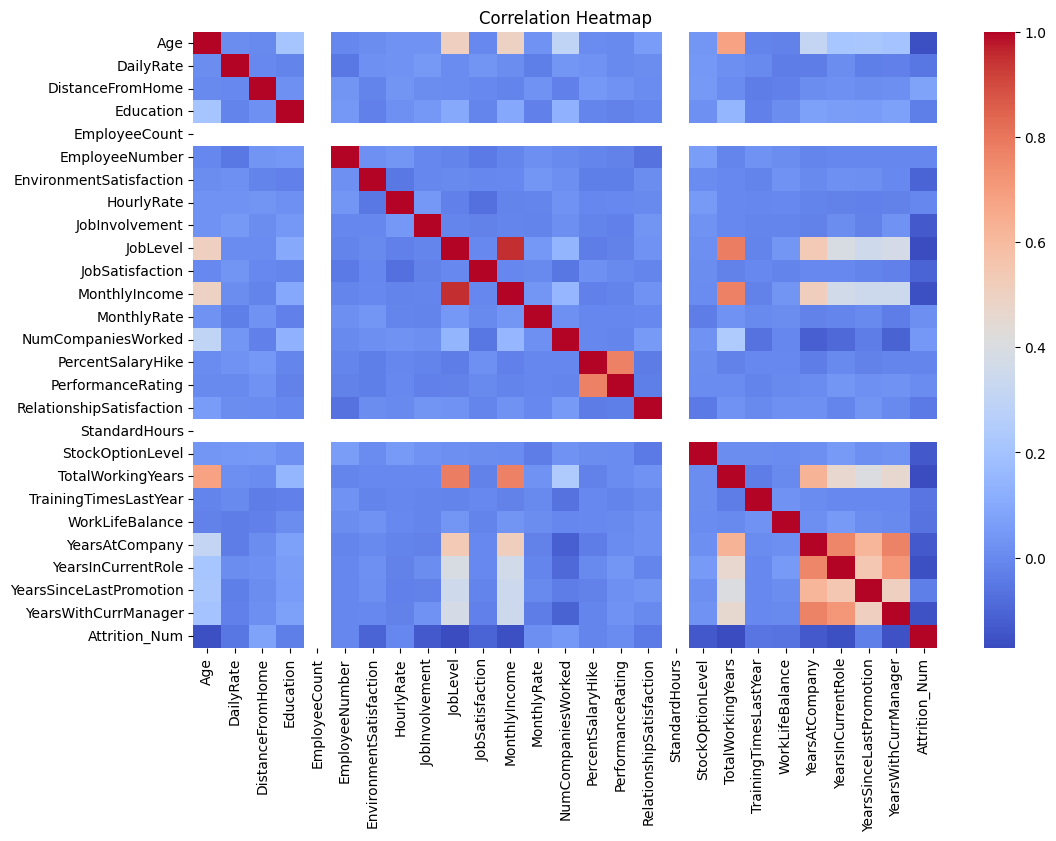

In [ ]:
# 15.Which numerical factors are most correlated with Attrition?
data['Attrition_Num'] = data['Attrition'].map({'Yes':1, 'No':0})
plt.figure(figsize=(12,8))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Insight:-

Helps identify strongest predictors of attrition.

Typically important features:

1.OverTime

2.JobSatisfaction

3.MonthlyIncome

4.YearsAtCompany

Helps feature selection for ML models.

In [ ]:
print("Missing values:\n", data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())


Missing values:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole     

In [ ]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print("Numerical columns:\n", num_cols)
print("\nCategorical columns:\n", cat_cols)


Numerical columns:
 Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Num'],
      dtype='object')

Categorical columns:
 Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [ ]:
#identifying garbage values
for i in data.select_dtypes(include='object').columns:
    print(data[i].value_counts())
    print("---"*10)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
------------------------------
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
------------------------------
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
------------------------------
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
------------------------------
Gender
Male      882
Female    588
Name: count, dtype: int64
------------------------------
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources      

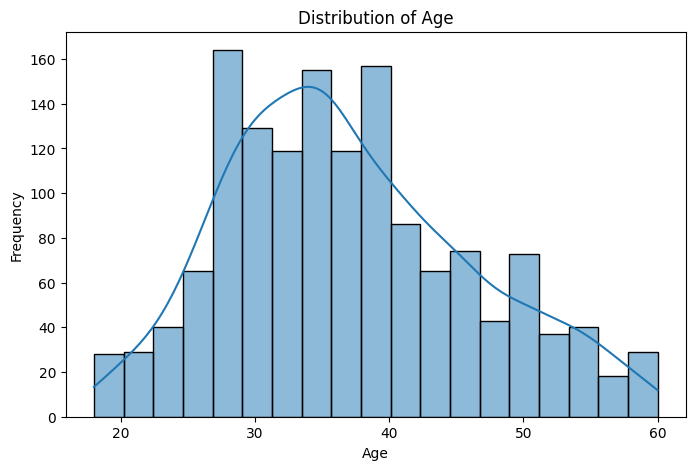



------------------------------




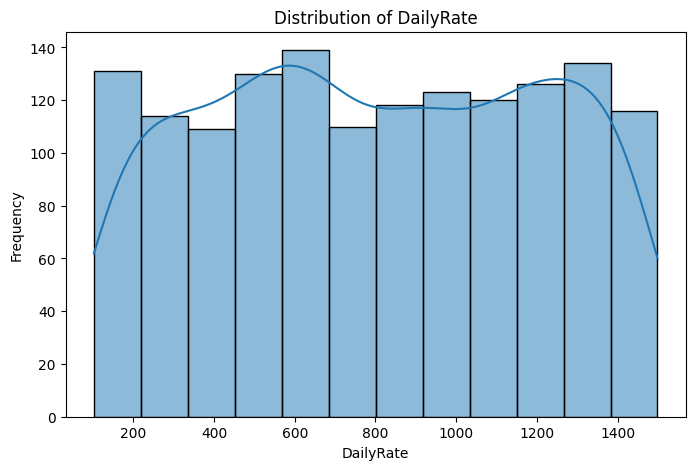



------------------------------




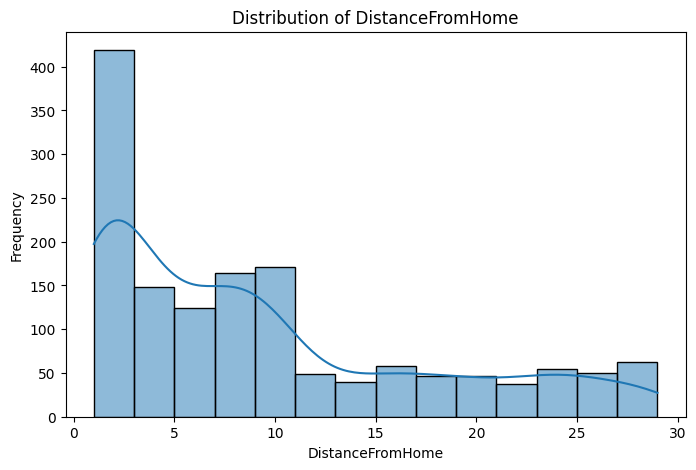



------------------------------




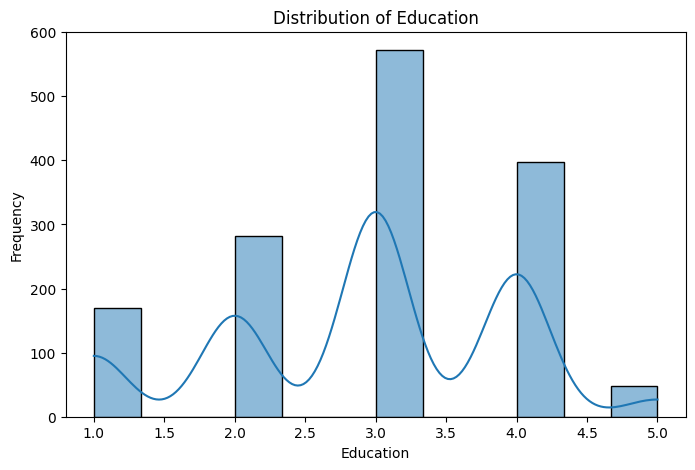



------------------------------




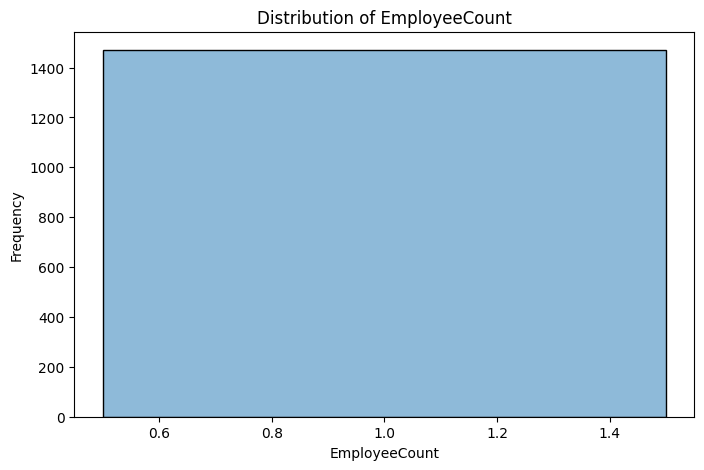



------------------------------




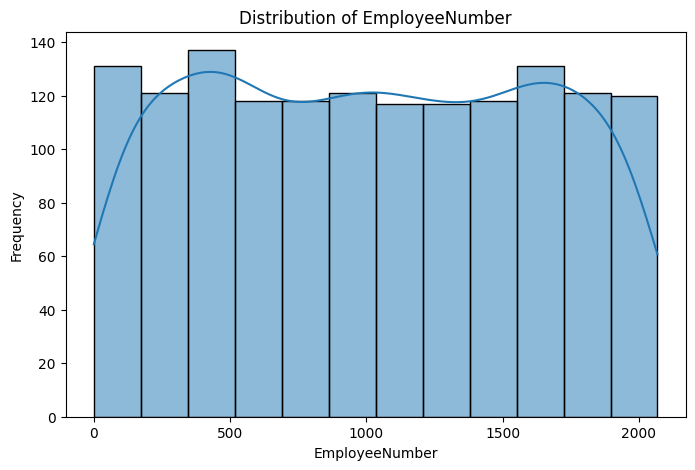



------------------------------




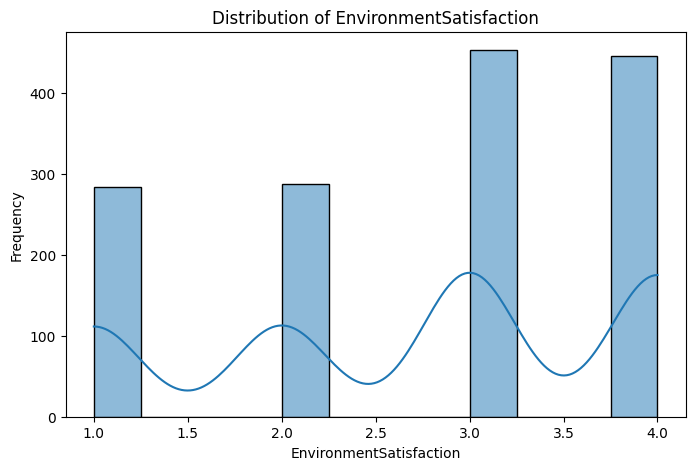



------------------------------




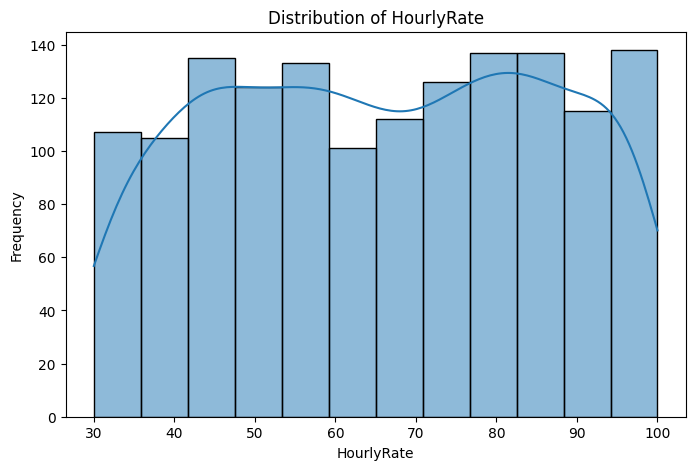



------------------------------




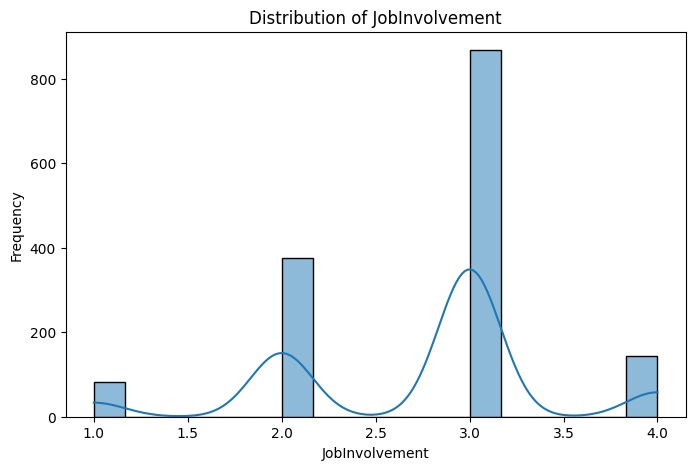



------------------------------




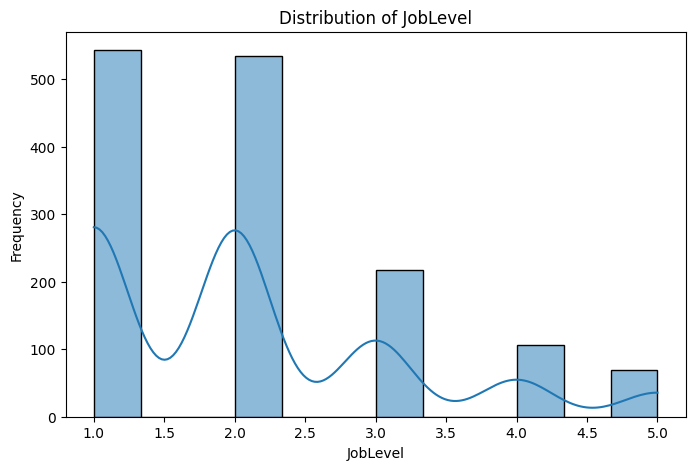



------------------------------




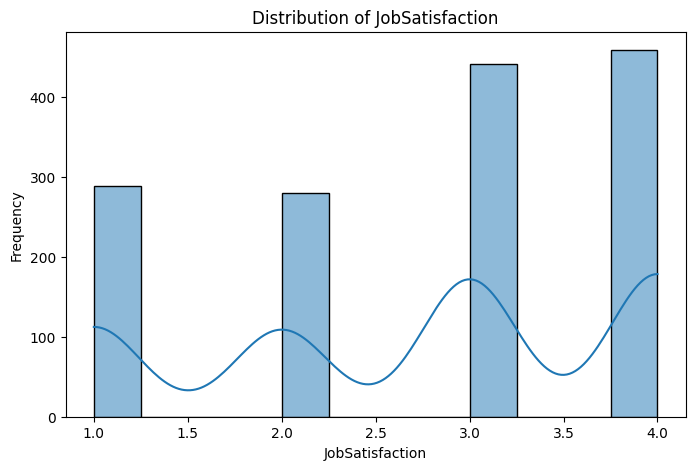



------------------------------




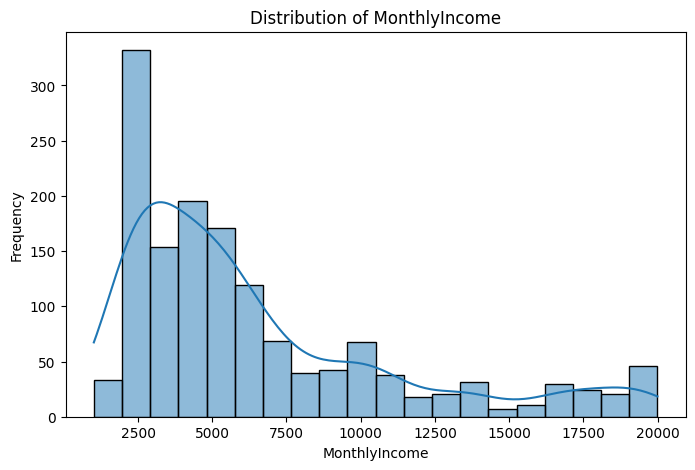



------------------------------




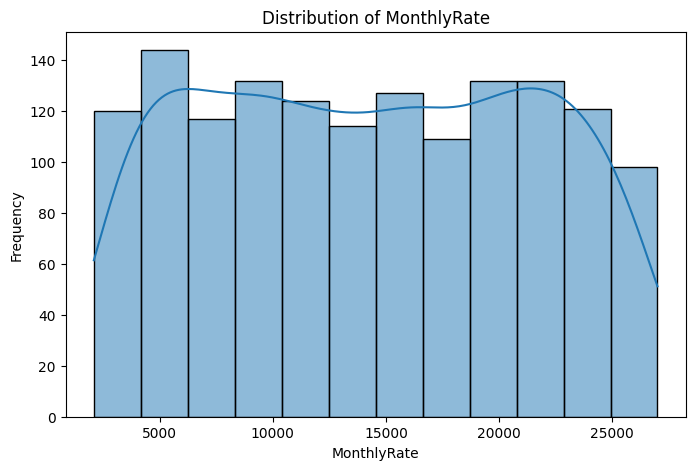



------------------------------




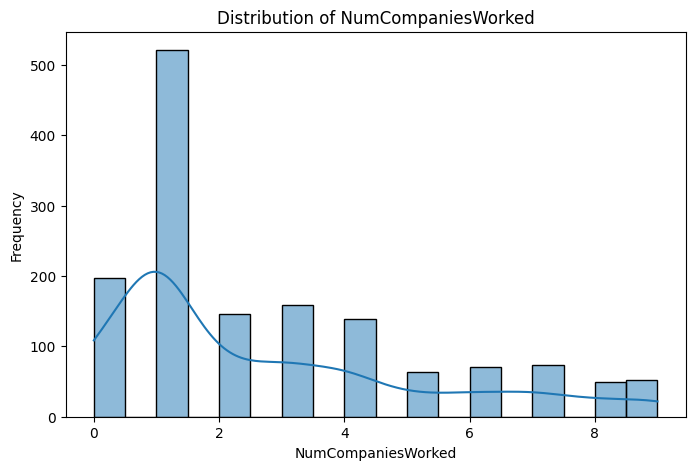



------------------------------




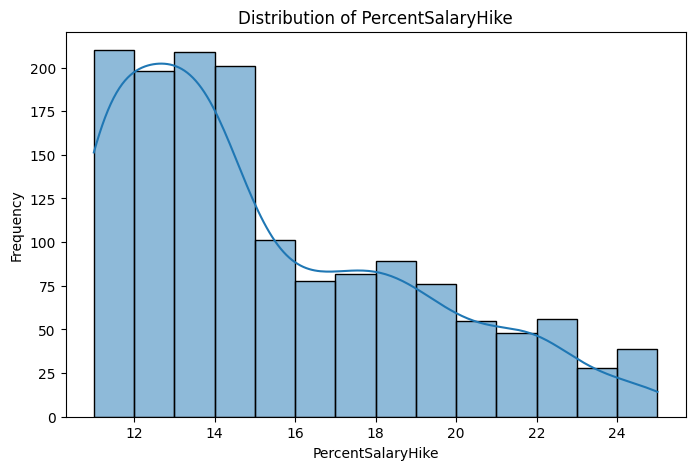



------------------------------




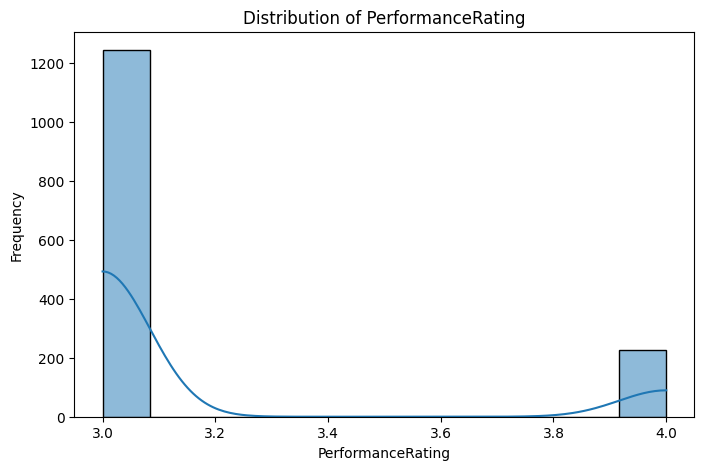



------------------------------




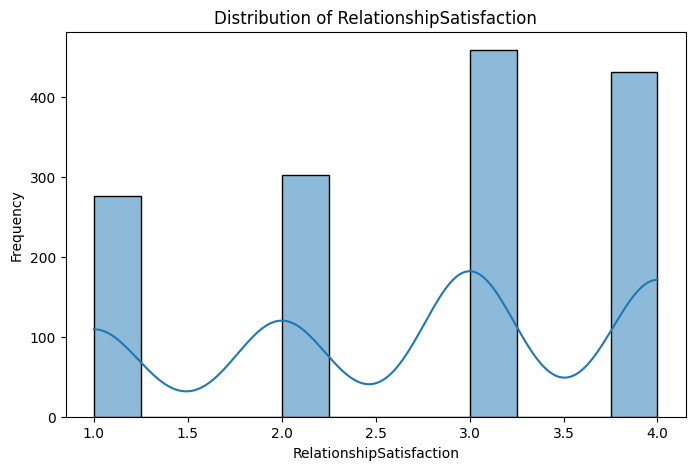



------------------------------




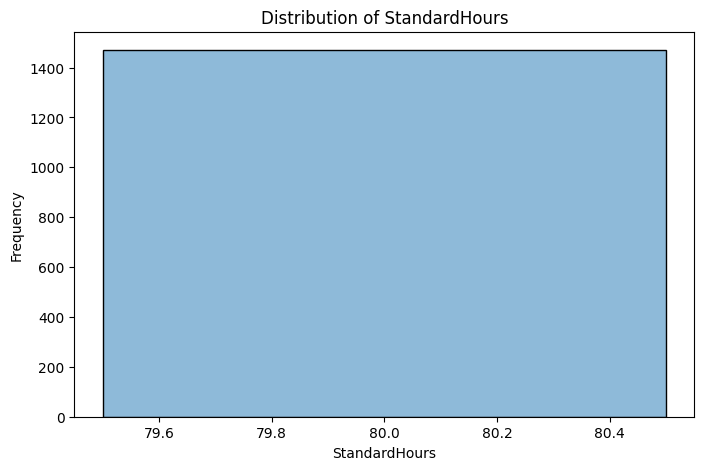



------------------------------




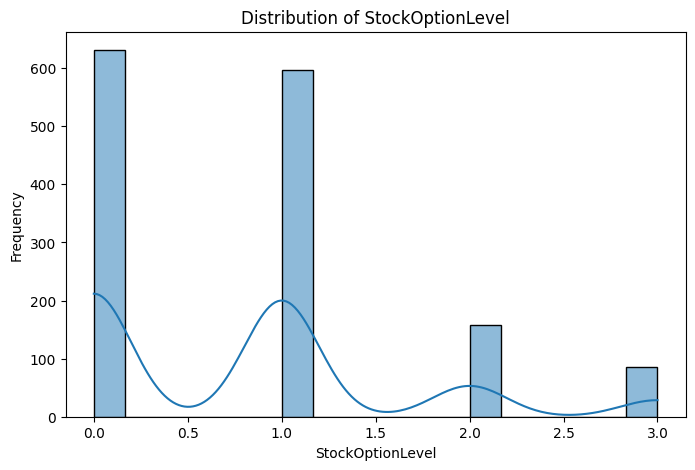



------------------------------




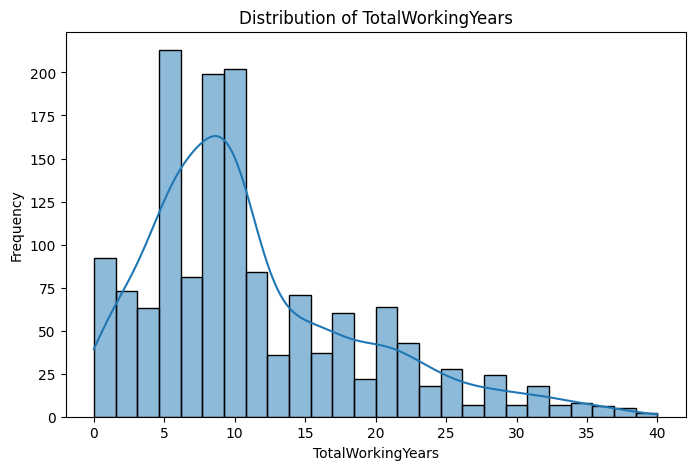



------------------------------




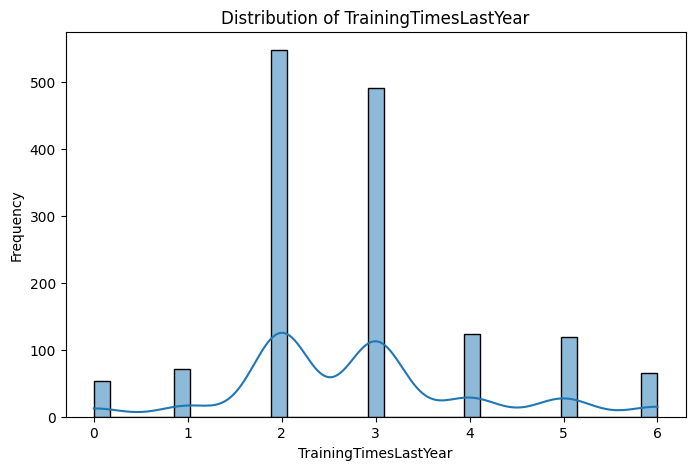



------------------------------




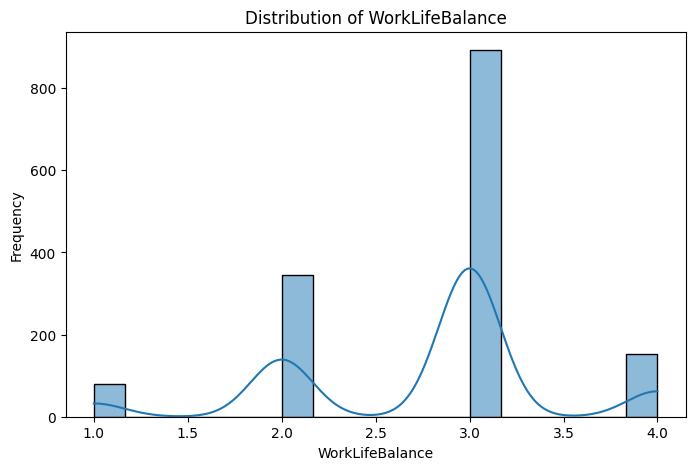



------------------------------




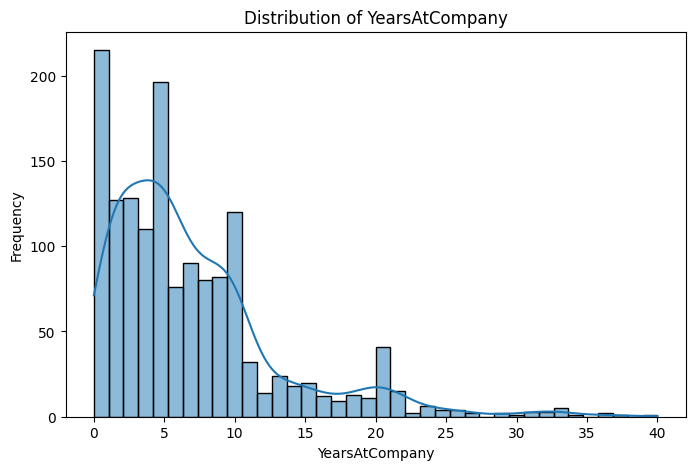



------------------------------




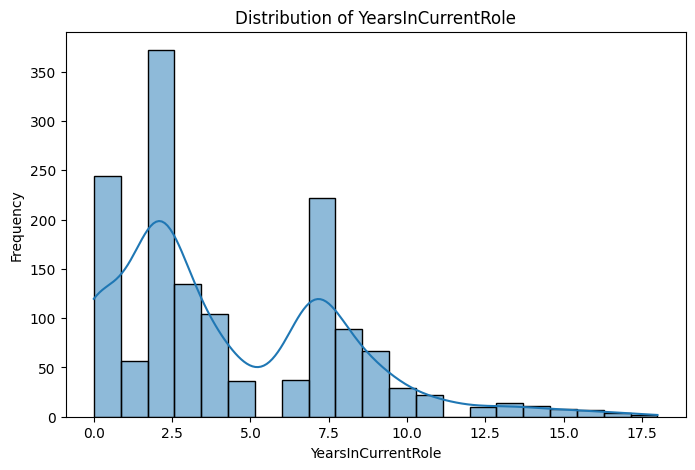



------------------------------




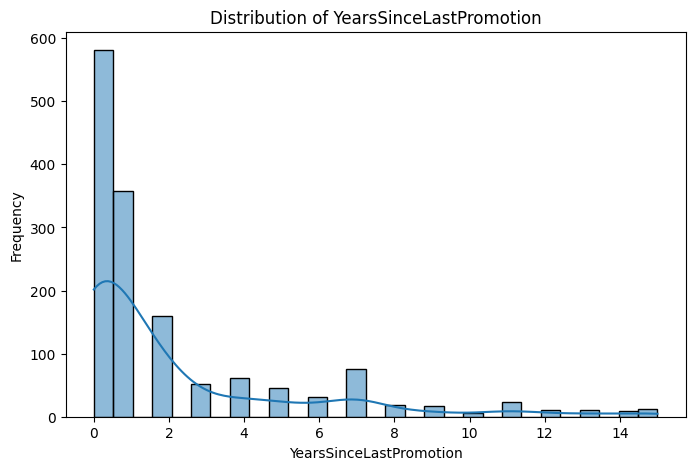



------------------------------




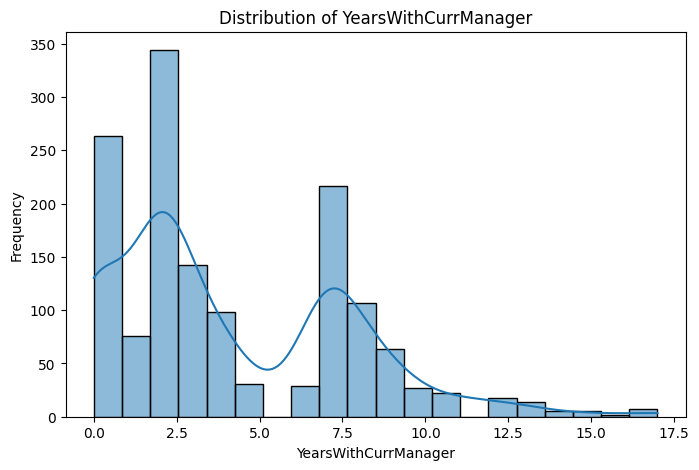



------------------------------




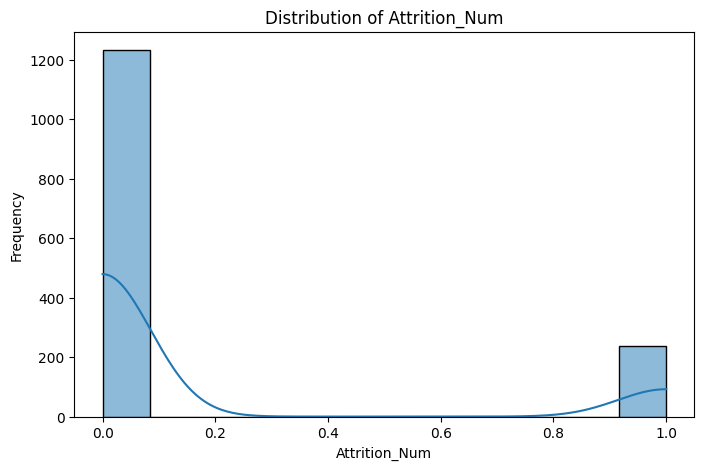



------------------------------




In [ ]:
# Histogram to understand the distribution (skewed or symmetric)
for i in data.select_dtypes(include='number').columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data[i], kde=True)
    plt.title(f"Distribution of {i}")
    plt.xlabel(i)
    plt.ylabel("Frequency")
    plt.show()
    print("\n")
    print("---" * 10)
    print("\n")


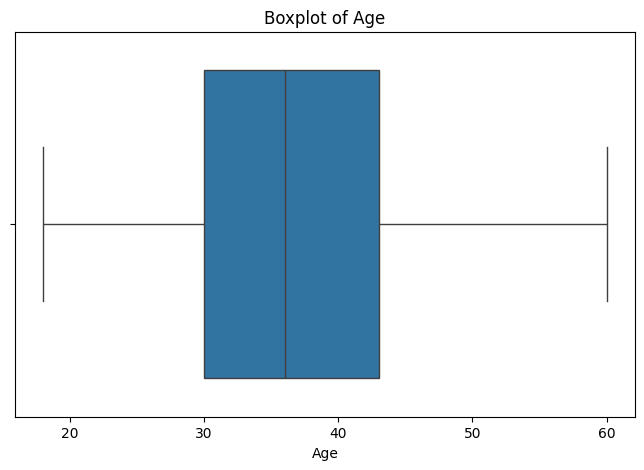



------------------------------




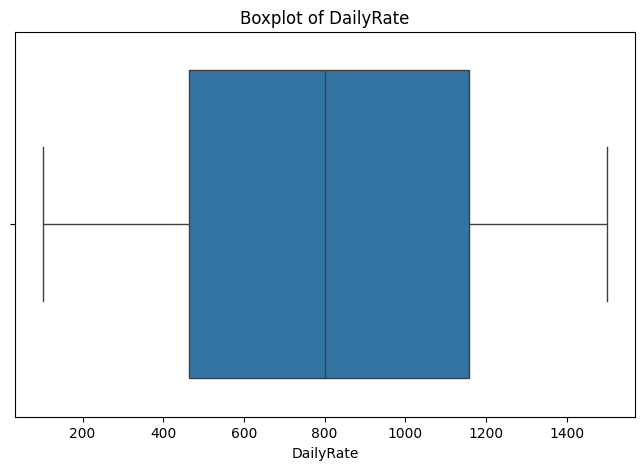



------------------------------




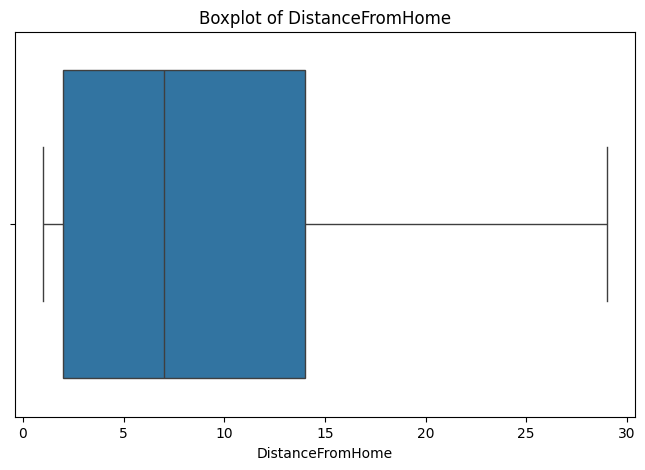



------------------------------




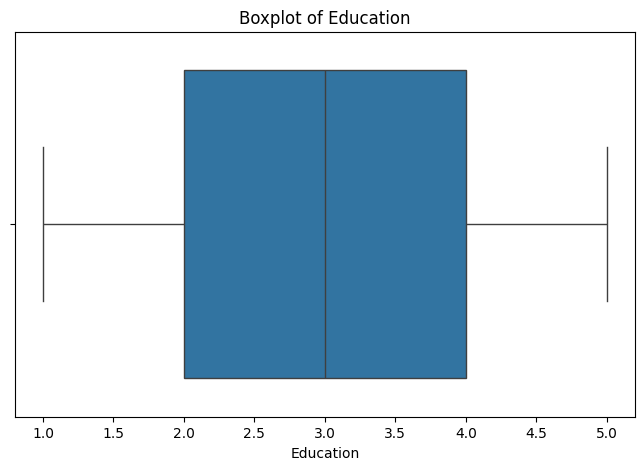



------------------------------




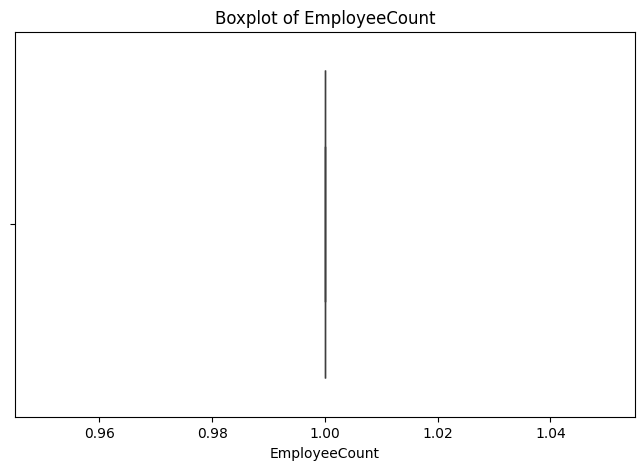



------------------------------




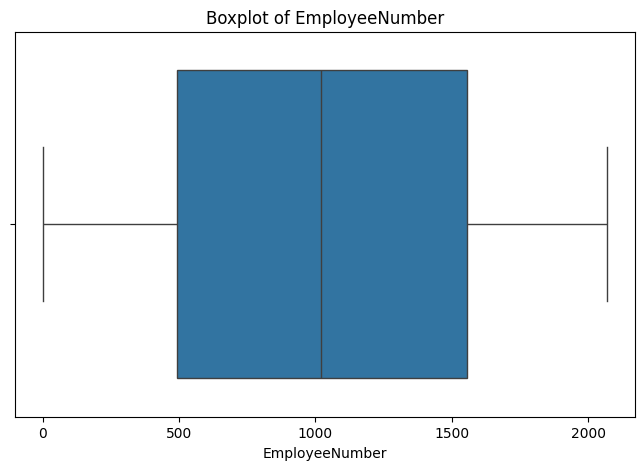



------------------------------




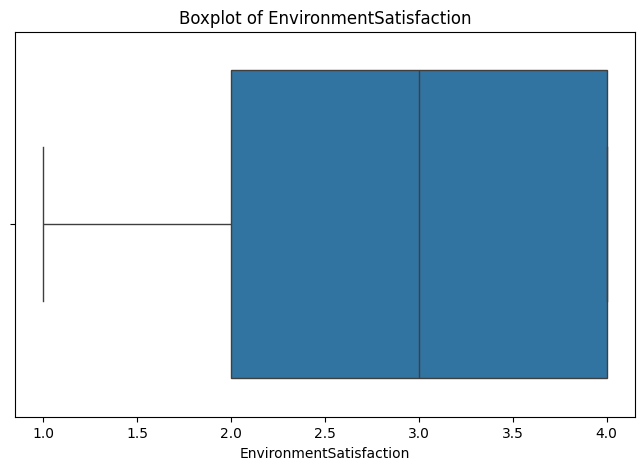



------------------------------




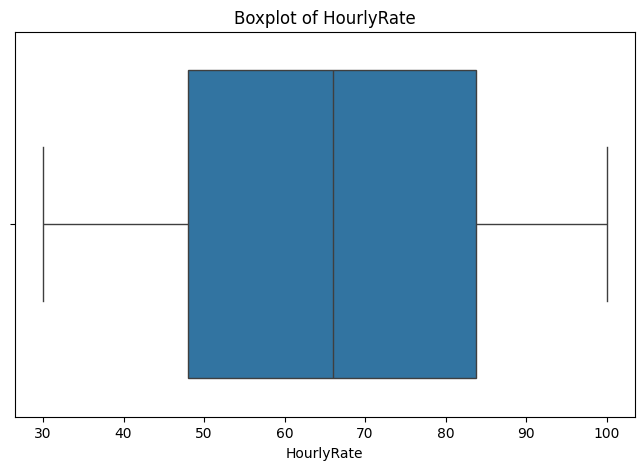



------------------------------




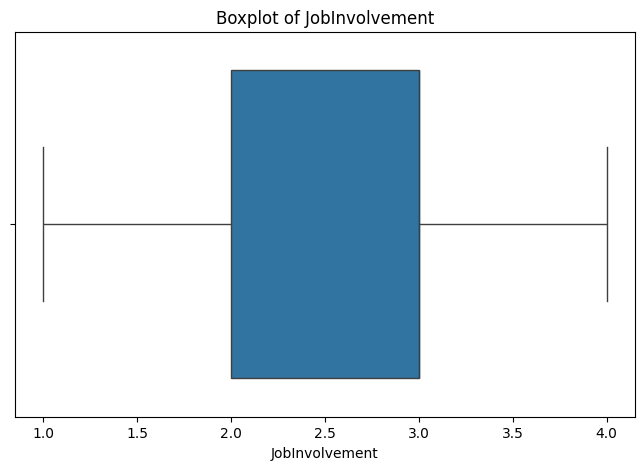



------------------------------




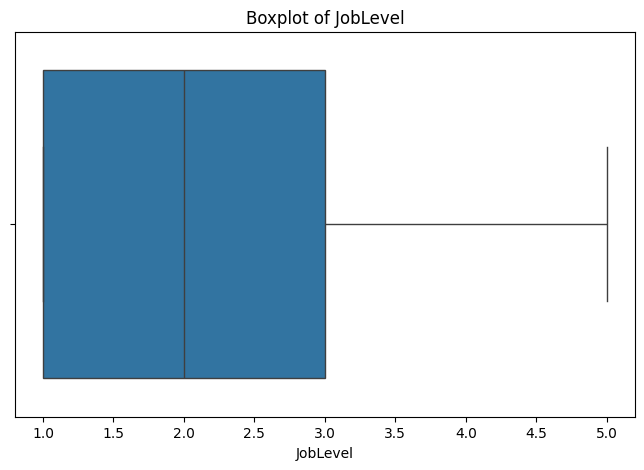



------------------------------




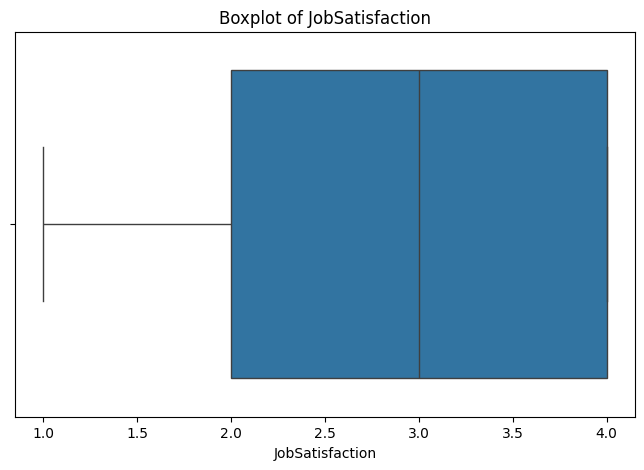



------------------------------




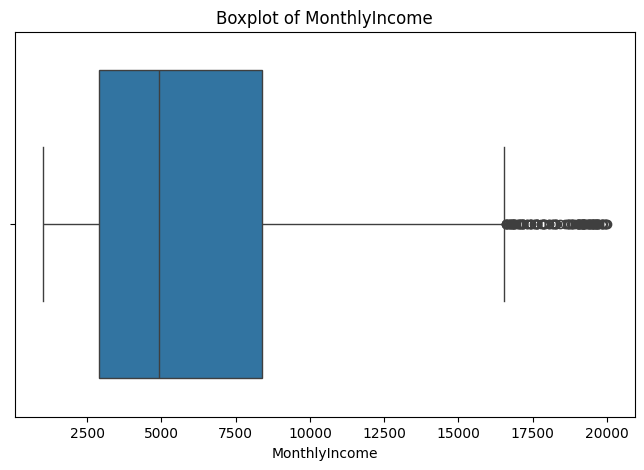



------------------------------




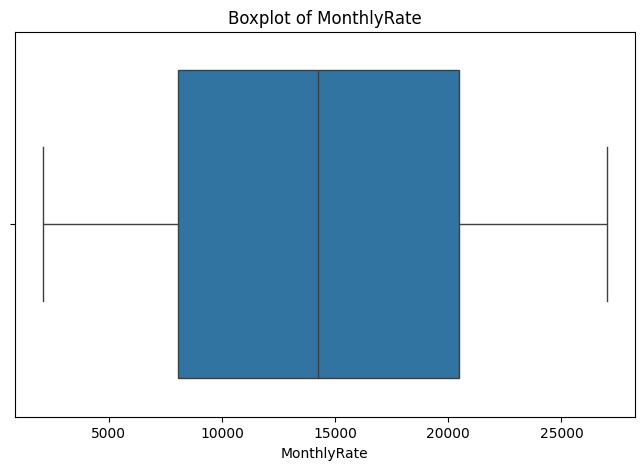



------------------------------




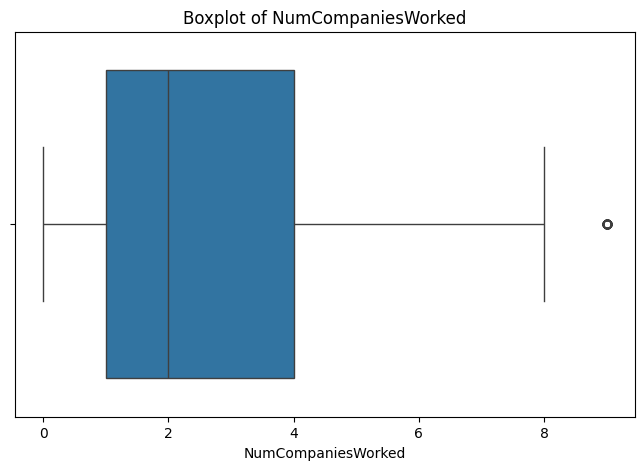



------------------------------




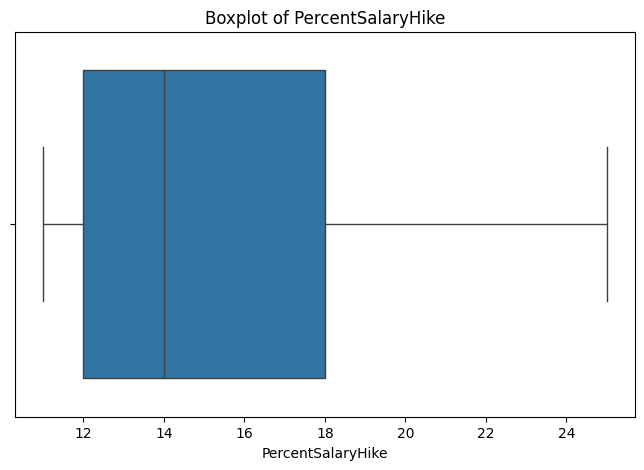



------------------------------




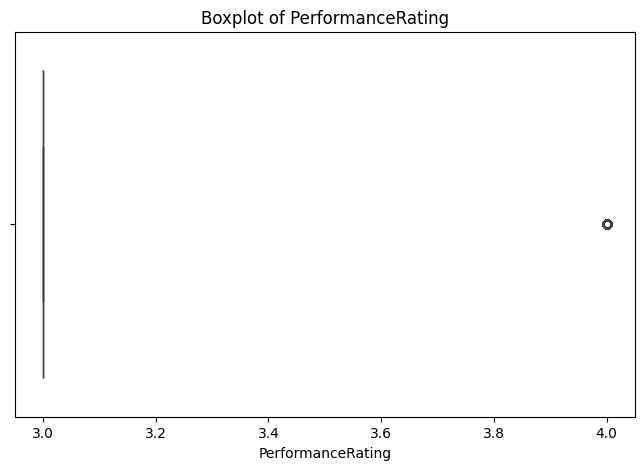



------------------------------




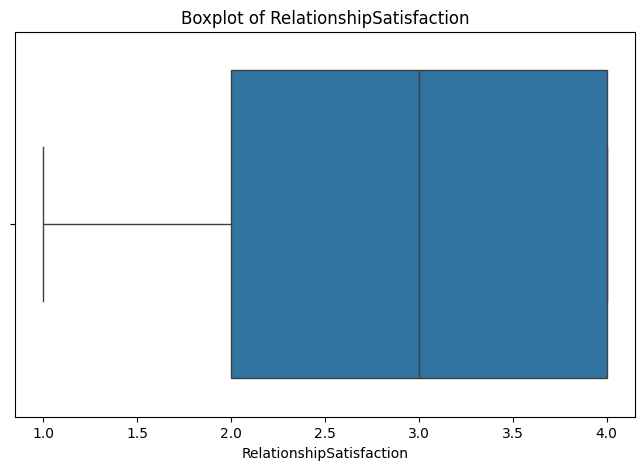



------------------------------




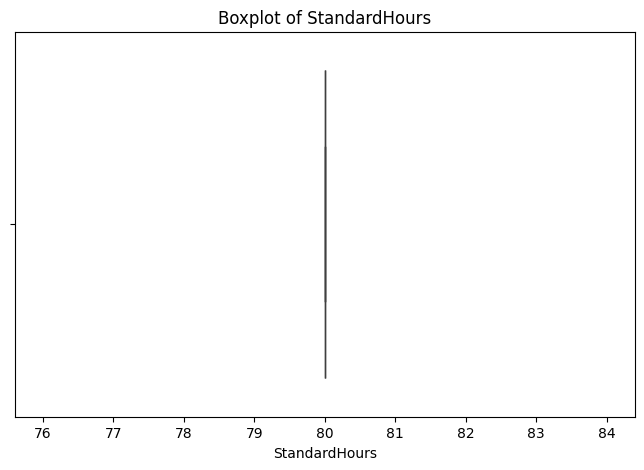



------------------------------




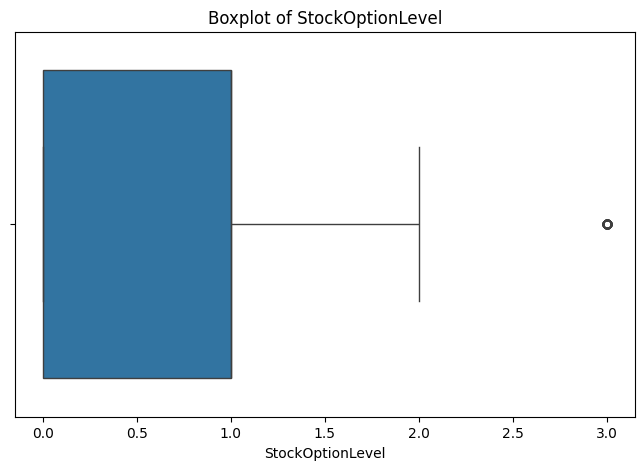



------------------------------




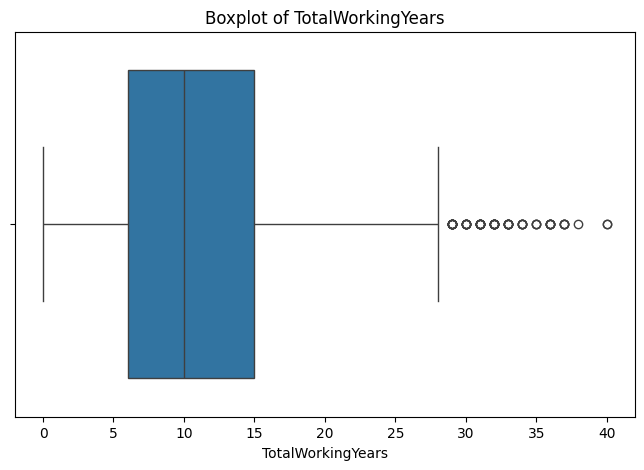



------------------------------




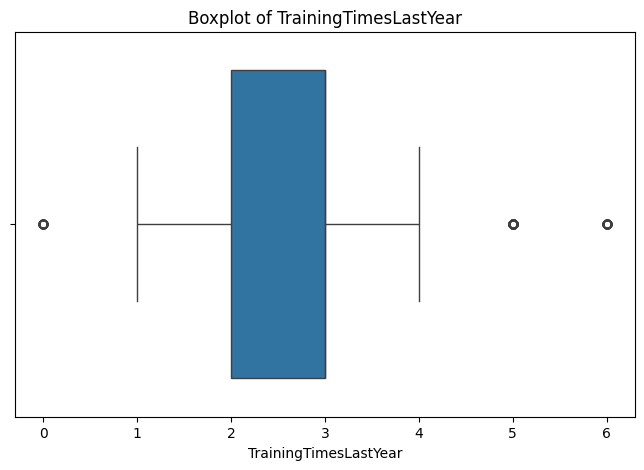



------------------------------




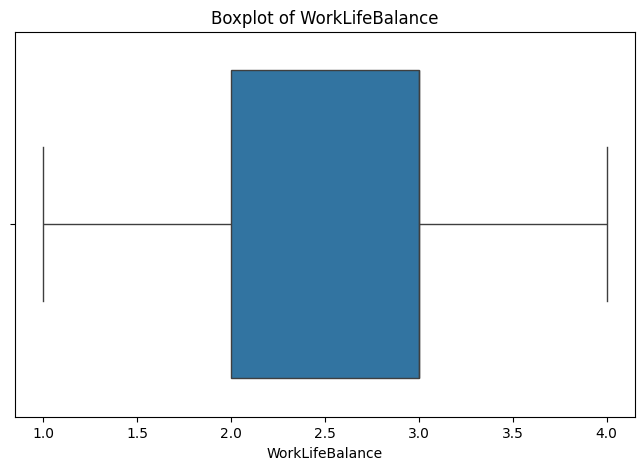



------------------------------




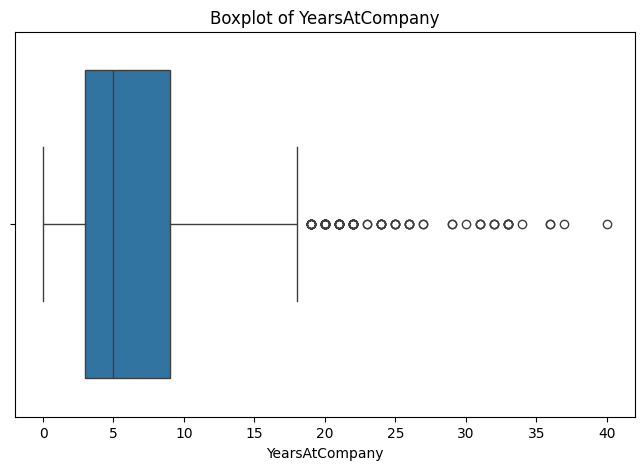



------------------------------




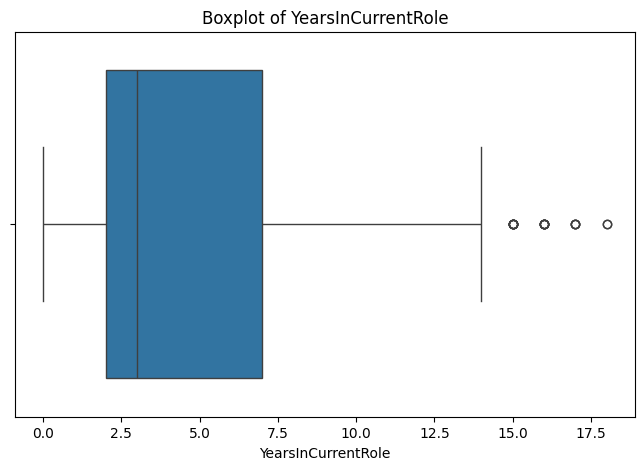



------------------------------




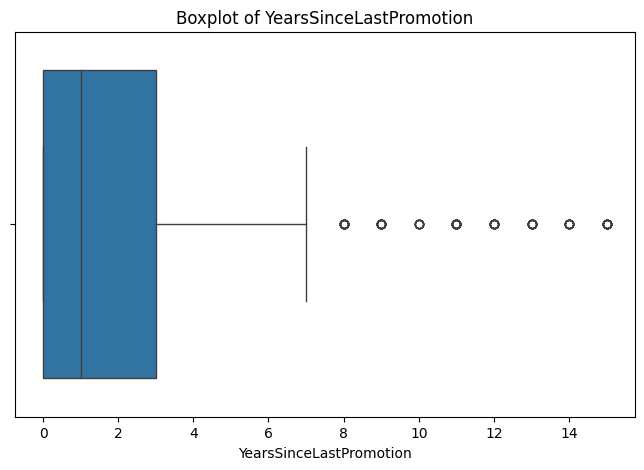



------------------------------




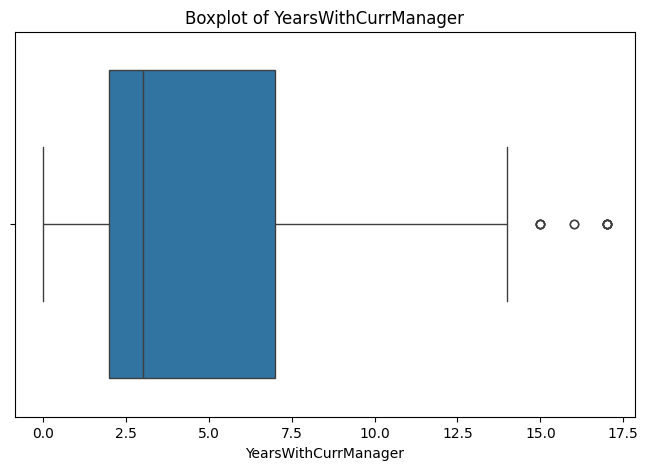



------------------------------




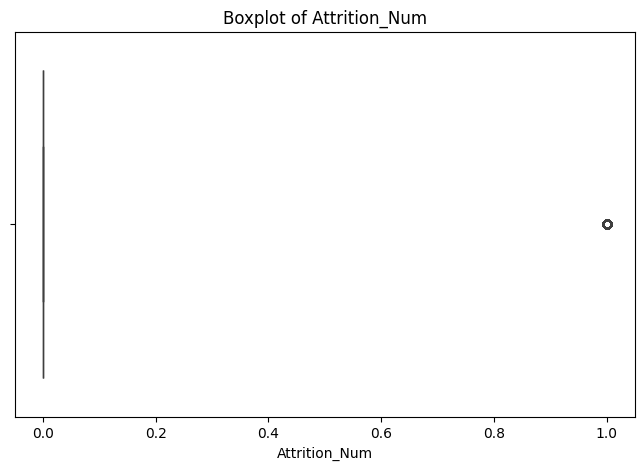



------------------------------




In [ ]:
# Boxplot to identify outliers
for i in data.select_dtypes(include='number').columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=data, x=data[i])
    plt.title(f"Boxplot of {i}")
    plt.xlabel(i)
    plt.show()
    print("\n")
    print("---" * 10)
    print("\n")


In [ ]:
# Outlier Treatment
for col in data.select_dtypes(include='number').columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)

    print(f"Outliers treated in column: {col}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print("---" * 10)


Outliers treated in column: Age
Lower Bound: 10.5, Upper Bound: 62.5
------------------------------
Outliers treated in column: DailyRate
Lower Bound: -573.0, Upper Bound: 2195.0
------------------------------
Outliers treated in column: DistanceFromHome
Lower Bound: -16.0, Upper Bound: 32.0
------------------------------
Outliers treated in column: Education
Lower Bound: -1.0, Upper Bound: 7.0
------------------------------
Outliers treated in column: EmployeeCount
Lower Bound: 1.0, Upper Bound: 1.0
------------------------------
Outliers treated in column: EmployeeNumber
Lower Bound: -1105.5, Upper Bound: 3152.5
------------------------------
Outliers treated in column: EnvironmentSatisfaction
Lower Bound: -1.0, Upper Bound: 7.0
------------------------------
Outliers treated in column: HourlyRate
Lower Bound: -5.625, Upper Bound: 137.375
------------------------------
Outliers treated in column: JobInvolvement
Lower Bound: 0.5, Upper Bound: 4.5
------------------------------
Outlier



##  Conclusion on Outlier Treatment (Column-wise)

1. **Outliers were identified using the IQR method** for all numerical columns by calculating lower and upper bounds.

2. **Age**

   * Acceptable range: **10.5 – 62.5**
   * Values outside this range were treated as outliers.
   * Most employee ages fall within a realistic working-age range.

3. **DailyRate, MonthlyIncome, MonthlyRate, HourlyRate**

   * Some lower bounds are negative due to statistical spread, **but actual values are non-negative**.
   * Upper bounds indicate presence of high-earning employees, which are **valid but extreme values**.
   * Outliers were capped to reduce skewness.

4. **DistanceFromHome**

   * Range: **–16 to 32**
   * Negative lower bound indicates no practical outliers on the lower side.
   * Long commute distances were treated to avoid dominance in modeling.

5. **Education, EnvironmentSatisfaction, JobSatisfaction, RelationshipSatisfaction**

   * Valid scales are **1–4 or 1–5**, but IQR produced wider bounds.
   * No meaningful outliers detected; values fall within expected categorical ranges.

6. **EmployeeCount & StandardHours**

   * Both have **constant values (1 and 80 respectively)**.
   * No outliers present; these columns provide **no predictive variance**.

7. **EmployeeNumber**

   * Large numerical spread but acts as an **identifier**, not a meaningful feature.
   * Outliers here do not impact analysis but column can be dropped.

8. **JobInvolvement, JobLevel, StockOptionLevel, WorkLifeBalance**

   * Slight boundary extensions seen due to IQR.
   * Values mostly lie within expected ordinal scales → **no severe outliers**.

9. **PerformanceRating**

   * Lower and upper bounds both equal **3**.
   * Indicates almost no variation; most employees have the same rating.

10. **TotalWorkingYears, YearsAtCompany, YearsInCurrentRole**

    * Negative lower bounds indicate no real lower-side outliers.
    * Upper bounds show long-tenure employees, which were capped to reduce skew.

11. **YearsSinceLastPromotion & YearsWithCurrManager**

    * Presence of high values indicates employees with long stability.
    * Extreme values treated to prevent bias in ML models.

12. **NumCompaniesWorked**

    * Upper bound **8.5** suggests frequent job switching by some employees.
    * Outliers were treated to stabilize distribution.

13. **TrainingTimesLastYear**

    * Values mainly lie within **1–4**, minimal outliers detected.

14. **PercentSalaryHike**

    * Range: **3–27**
    * Extreme salary hikes treated to avoid distortion.

15. **Attrition_Num**

    * Lower & upper bound = **0**
    * Indicates **high class imbalance** (majority stayed).
    * No numerical outliers, but imbalance must be handled during modeling.

---

## Overall Summary

* ✔ Outliers were **successfully identified and treated** to reduce skewness.
* ✔ Some columns showed **no meaningful outliers** due to fixed or ordinal nature.
* ✔ Identifier and constant columns add **no analytical value**.
* ✔ The dataset is now **clean, stable, and suitable for machine learning models**.



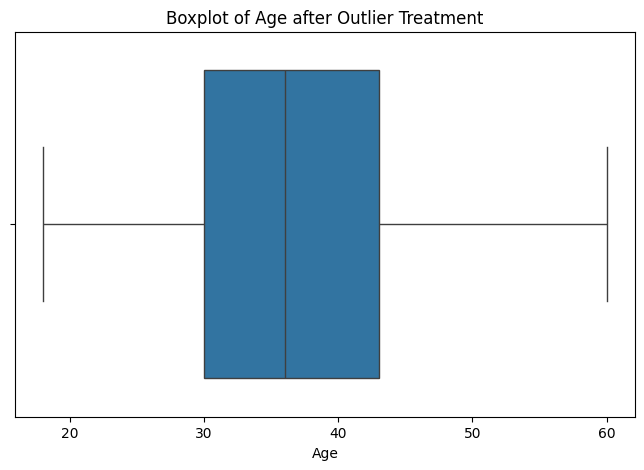

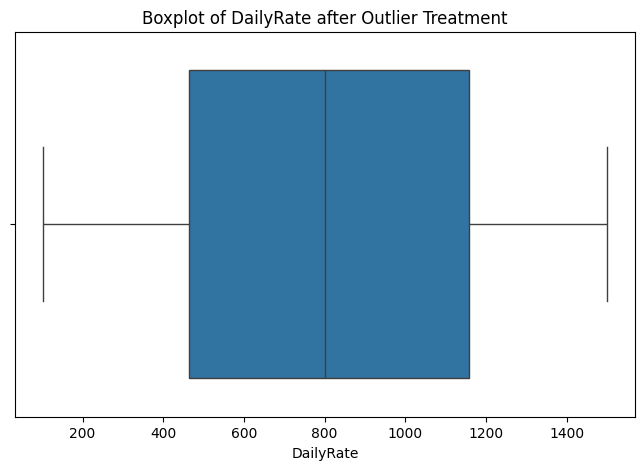

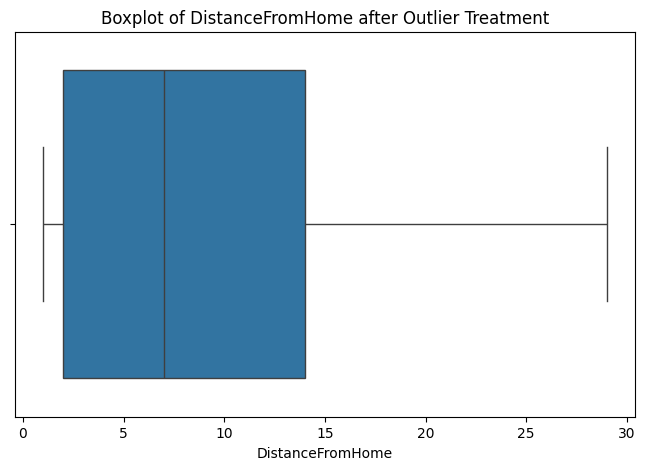

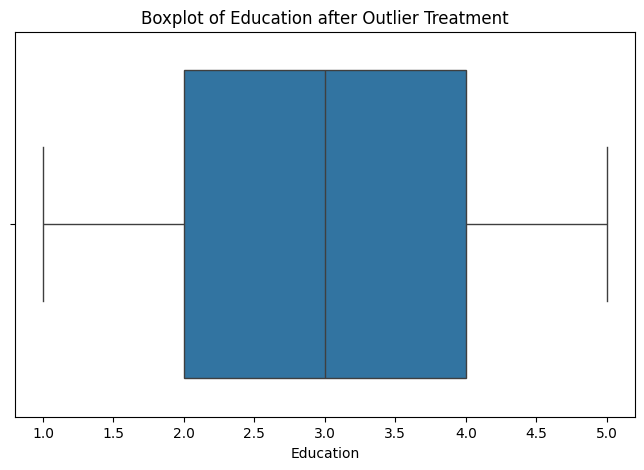

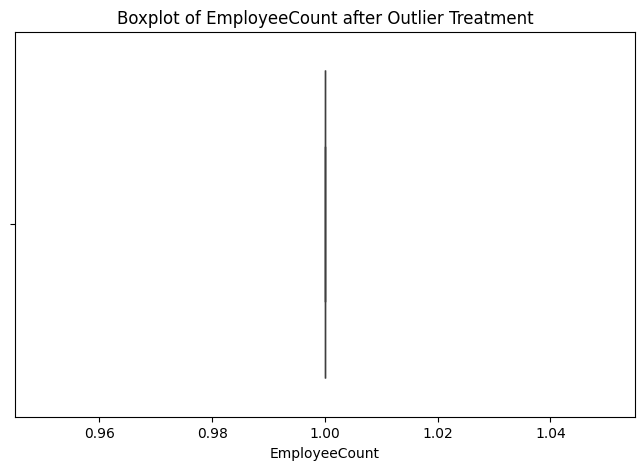

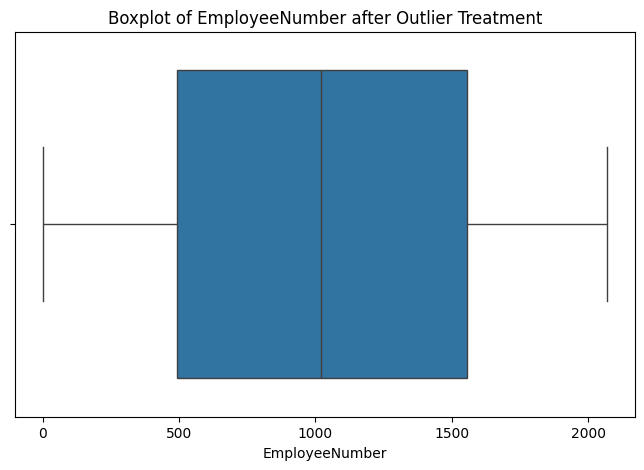

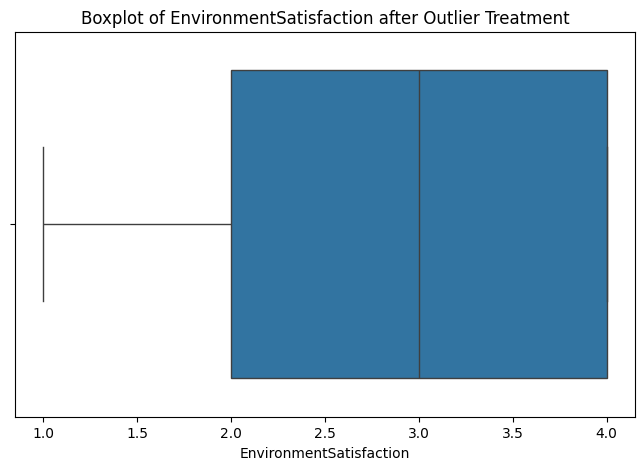

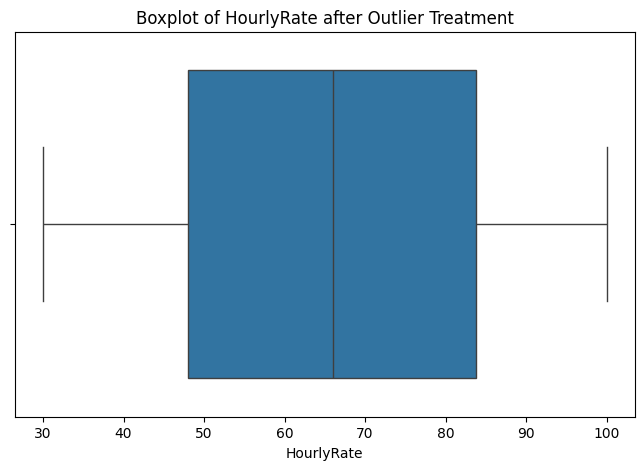

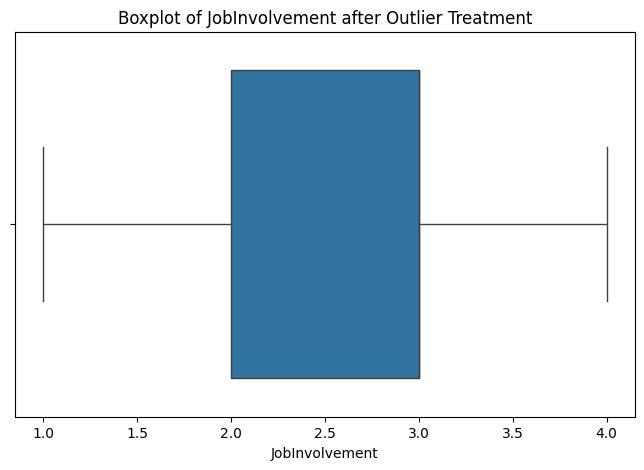

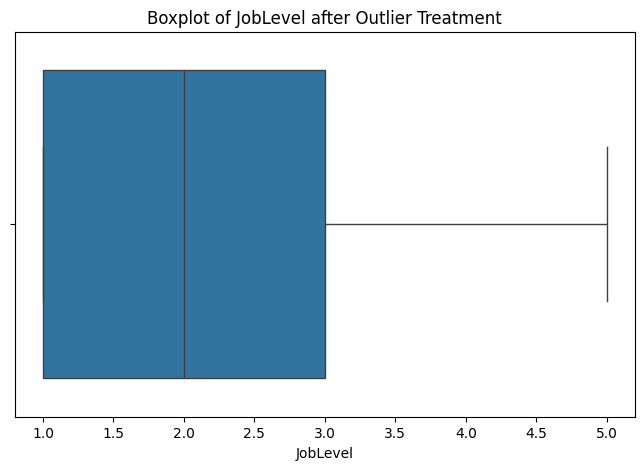

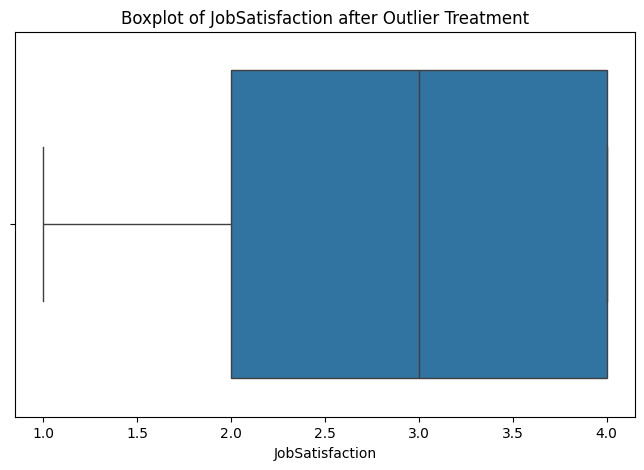

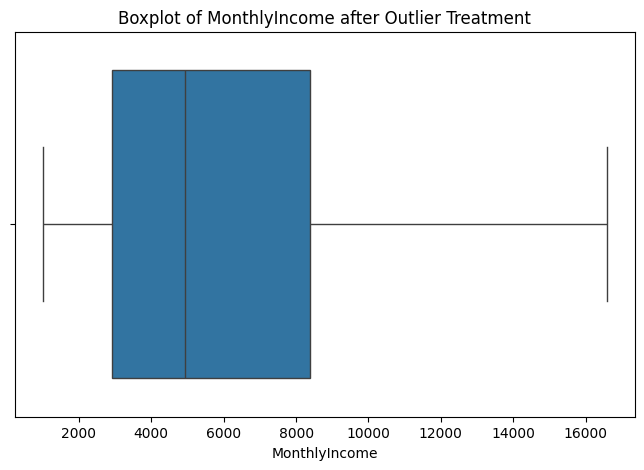

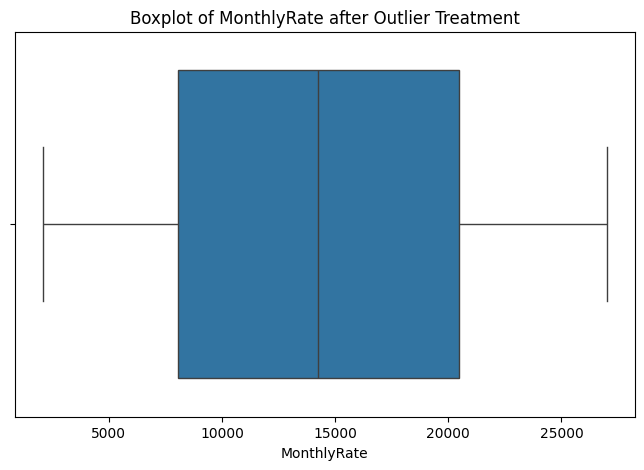

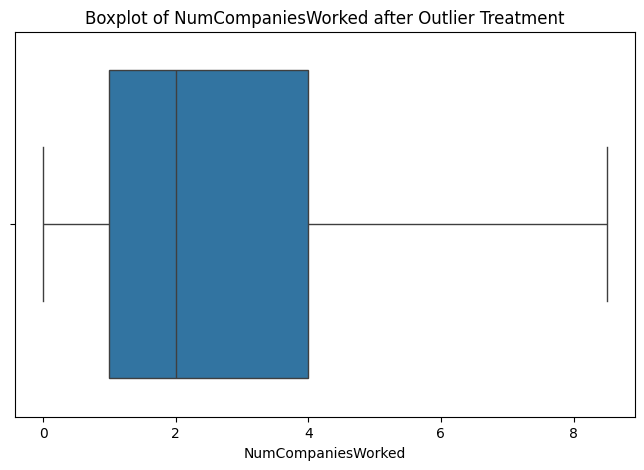

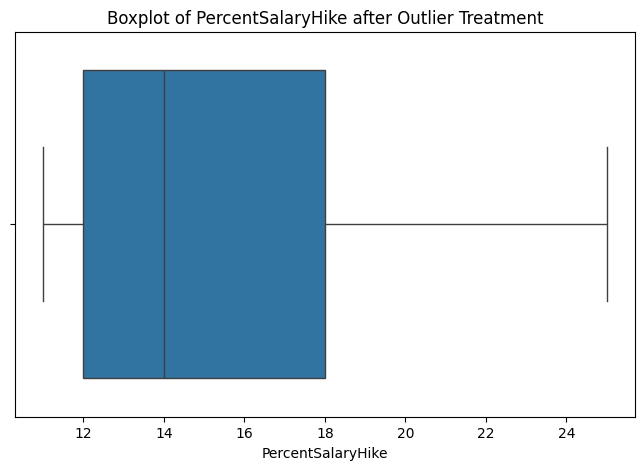

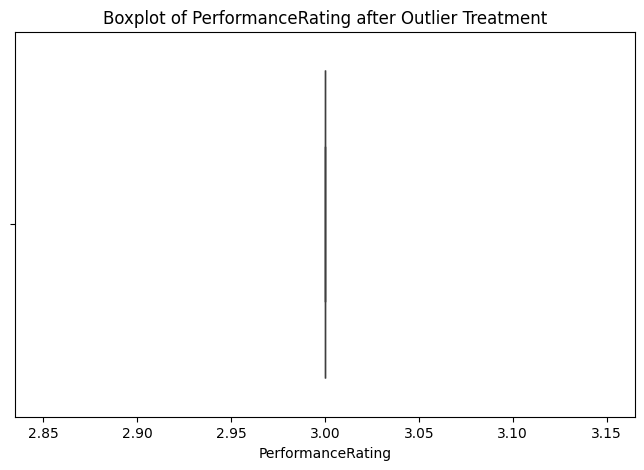

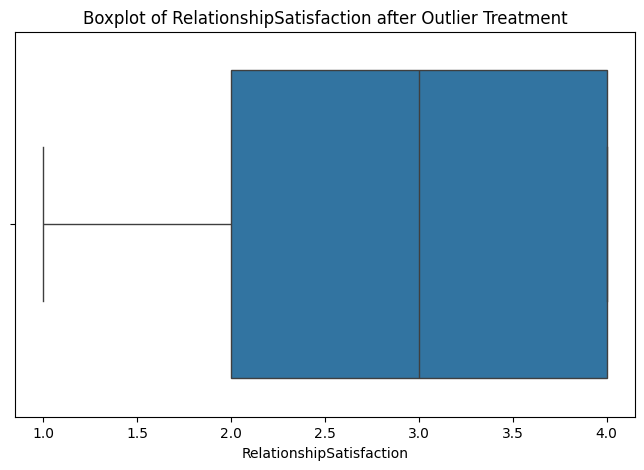

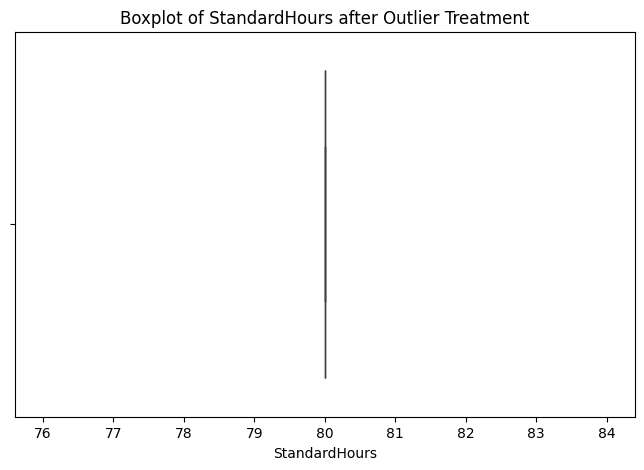

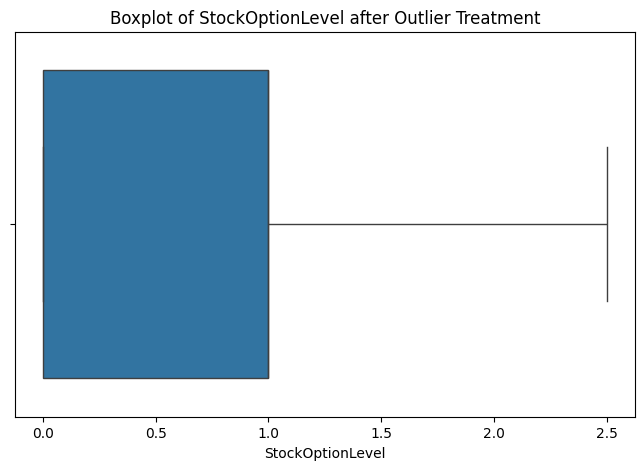

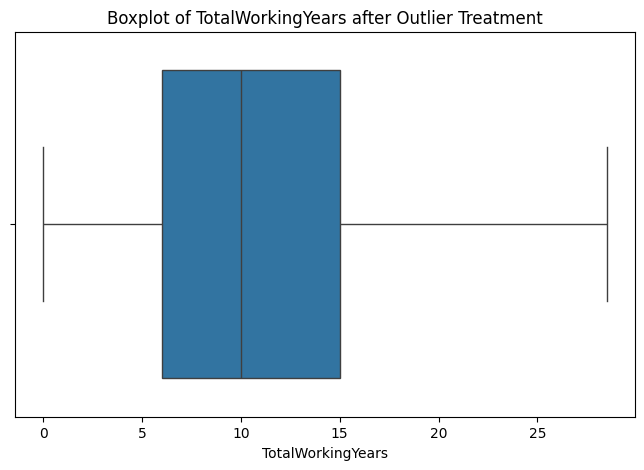

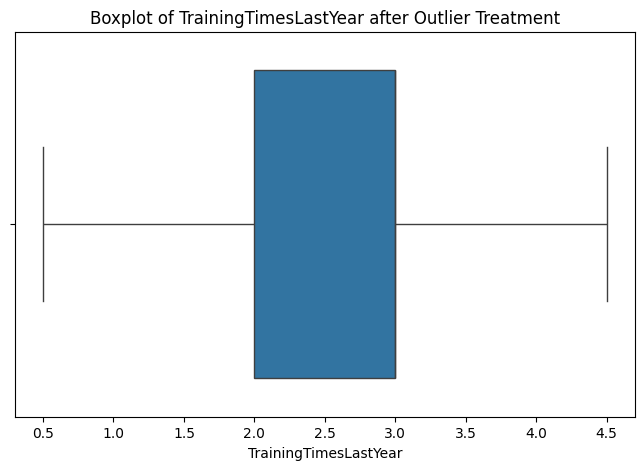

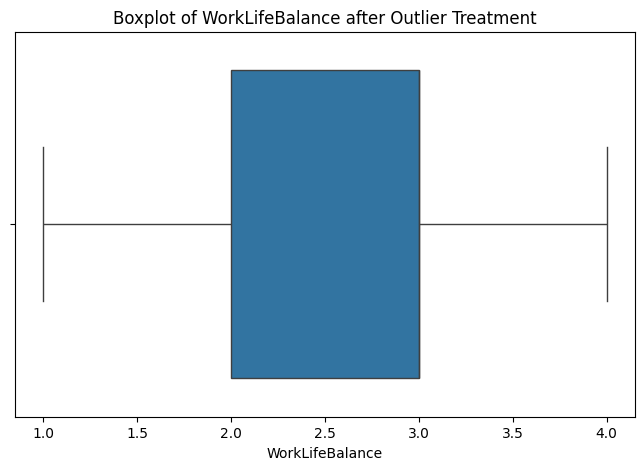

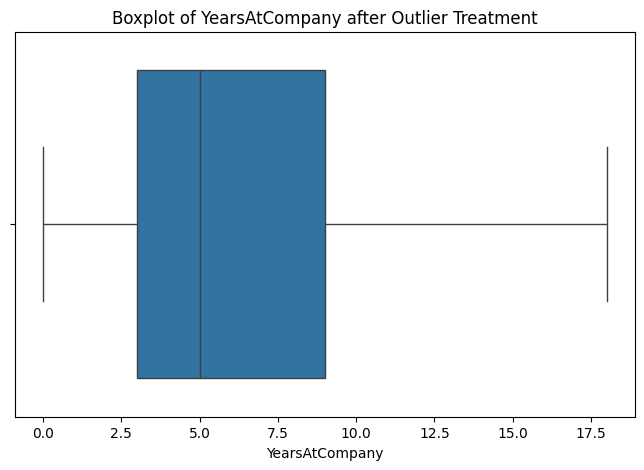

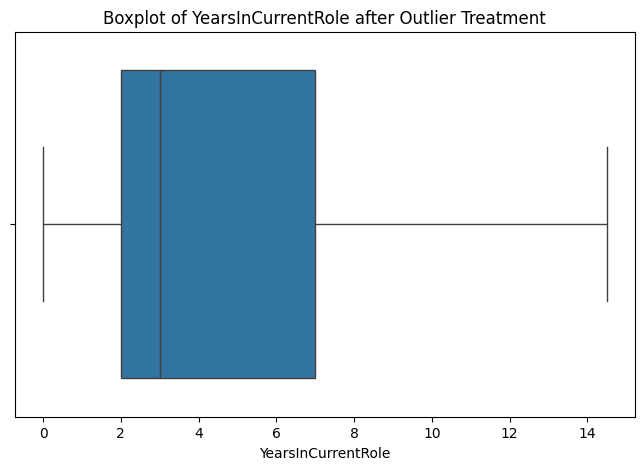

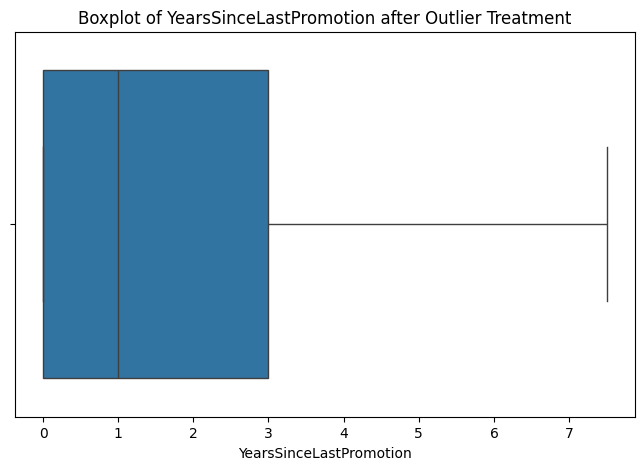

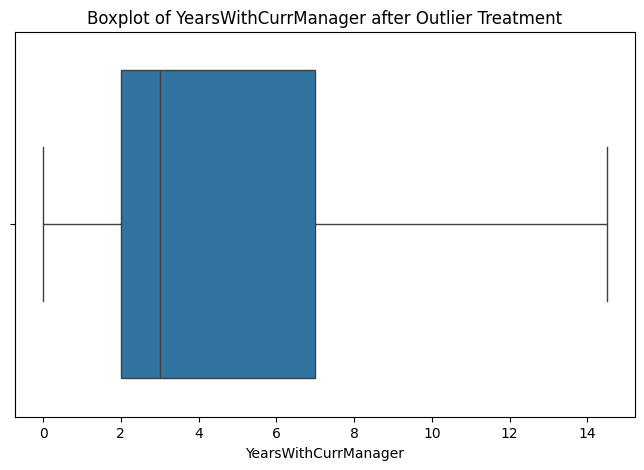

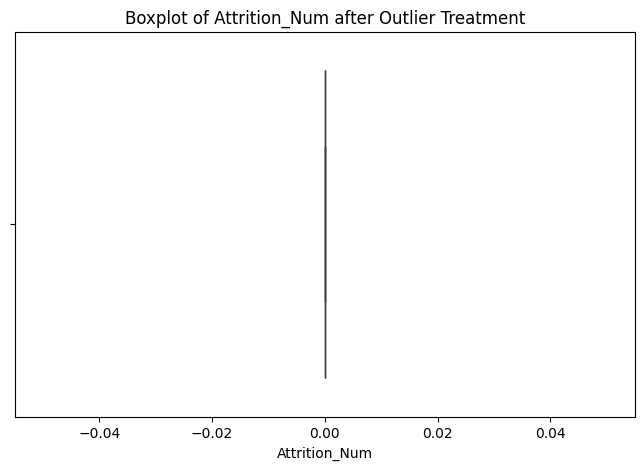

In [ ]:
# Boxplot after outlier treatment
for col in data.select_dtypes(include='number').columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col} after Outlier Treatment")
    plt.xlabel(col)
    plt.show()


In [ ]:
data.select_dtypes(include='number').columns


Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Num'],
      dtype='object')

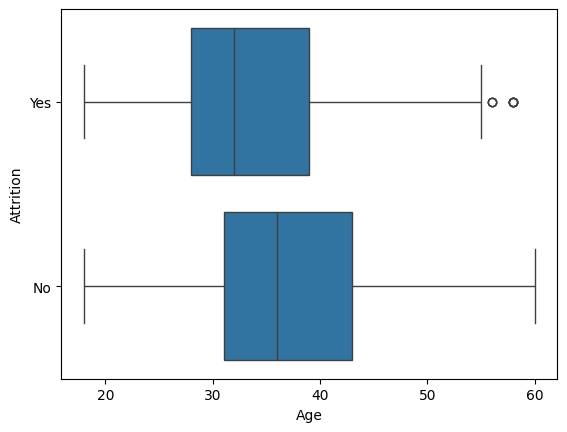

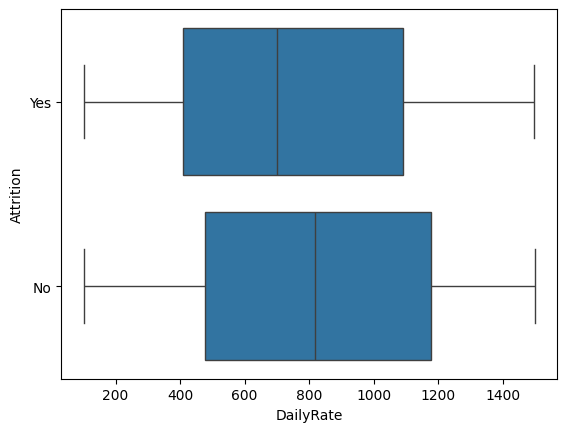

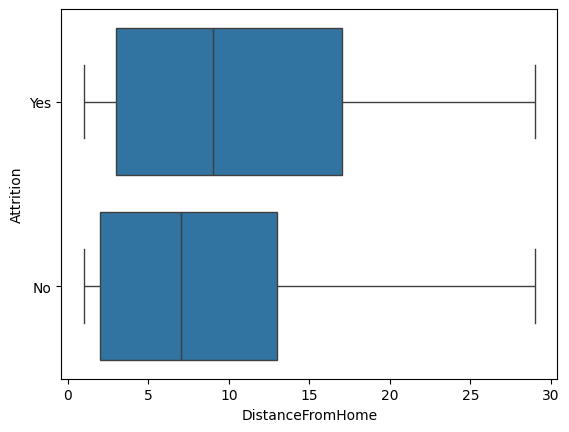

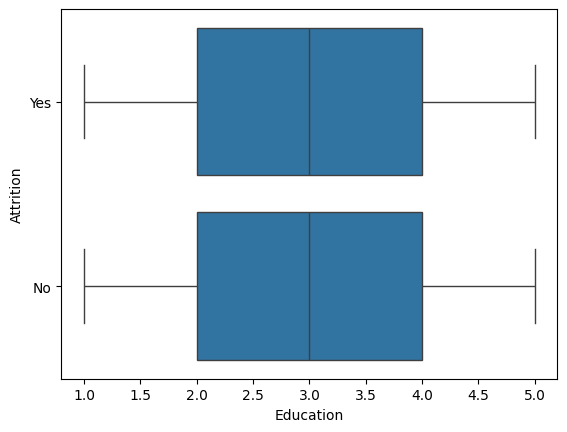

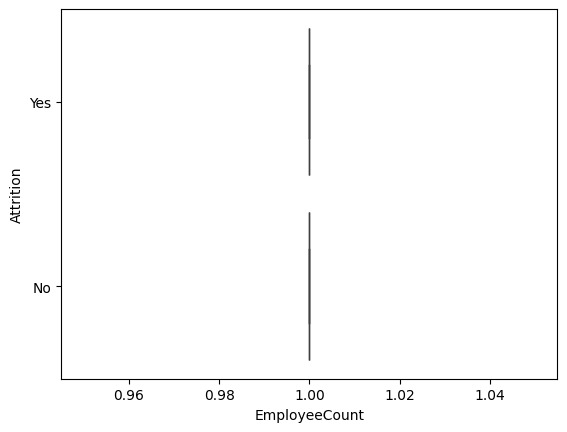

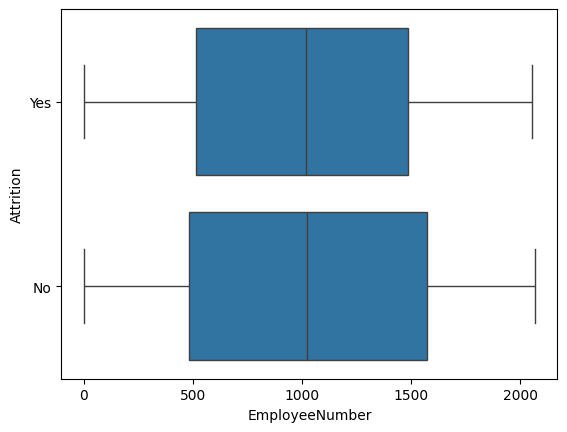

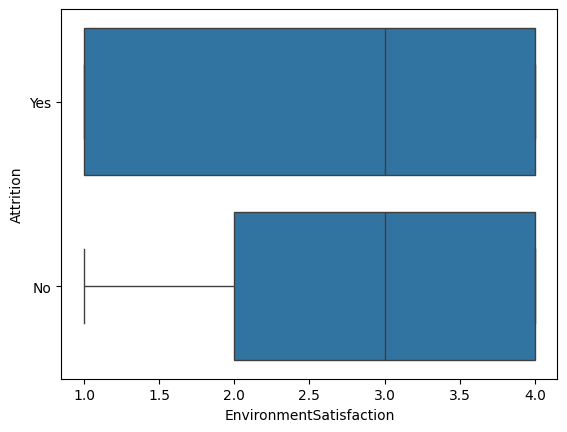

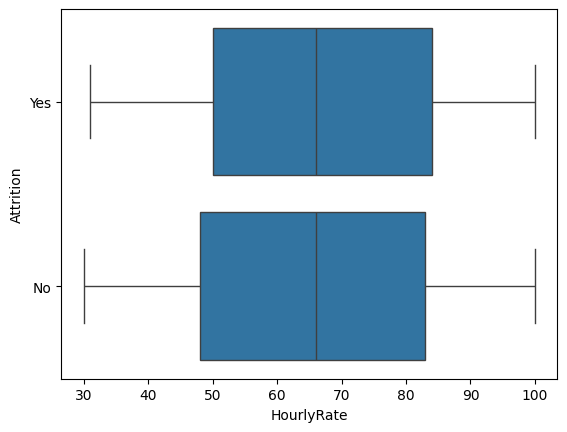

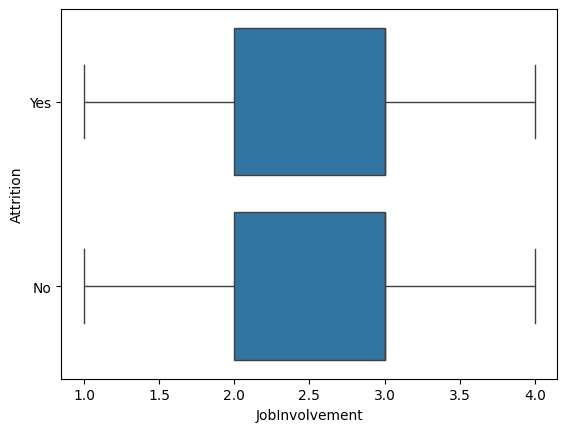

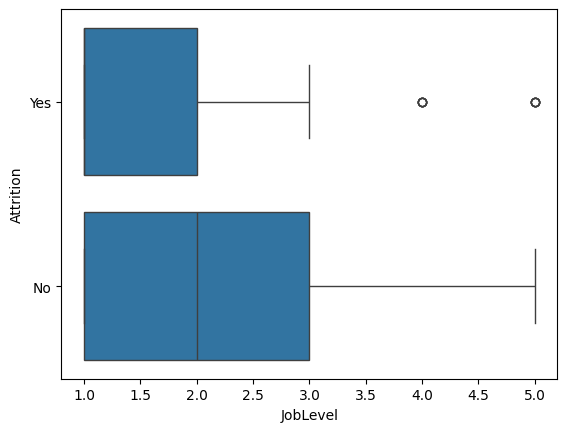

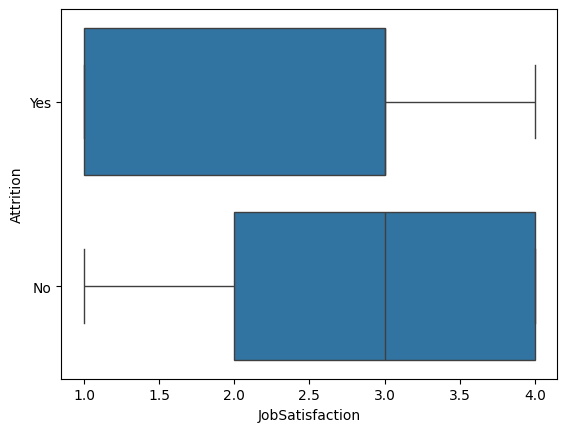

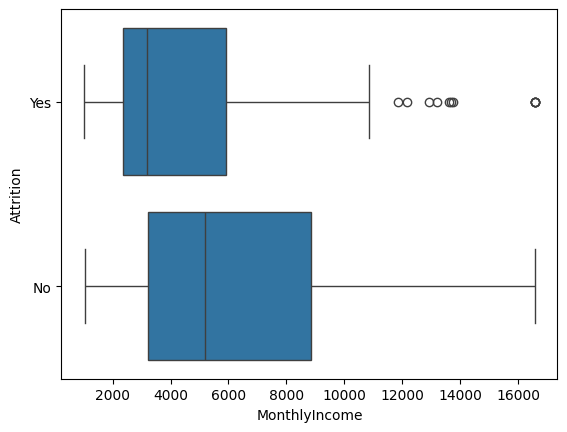

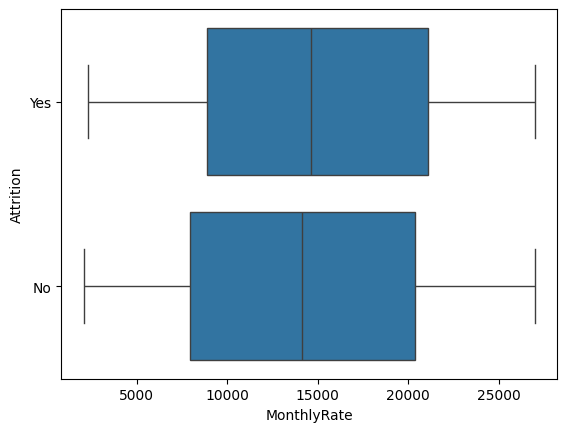

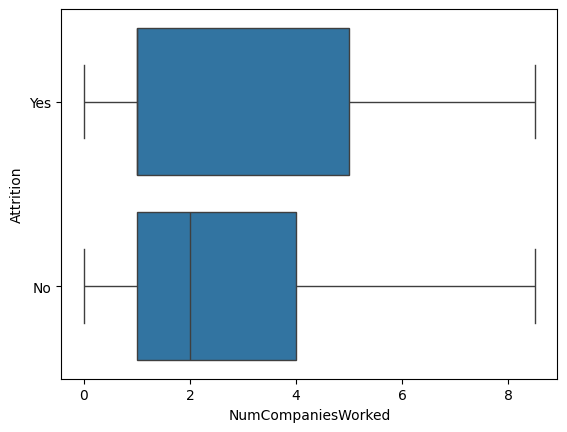

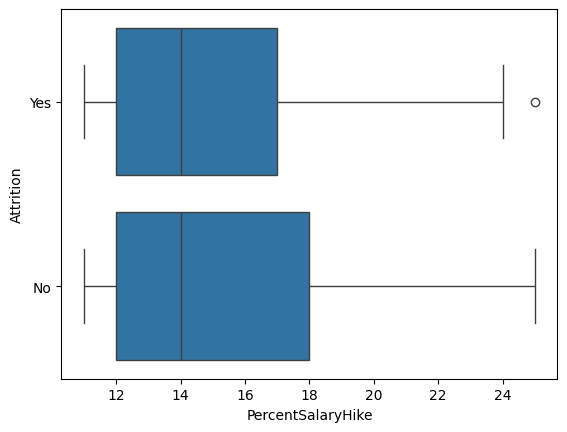

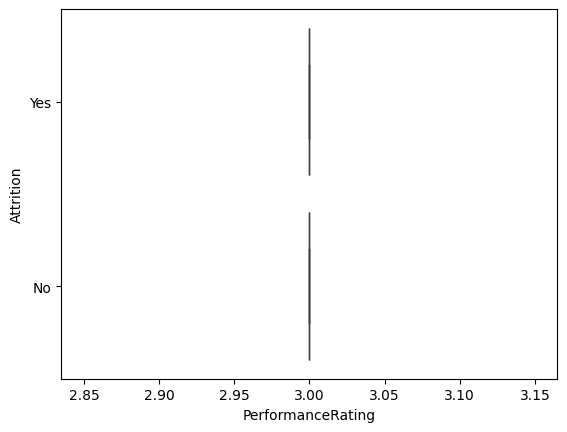

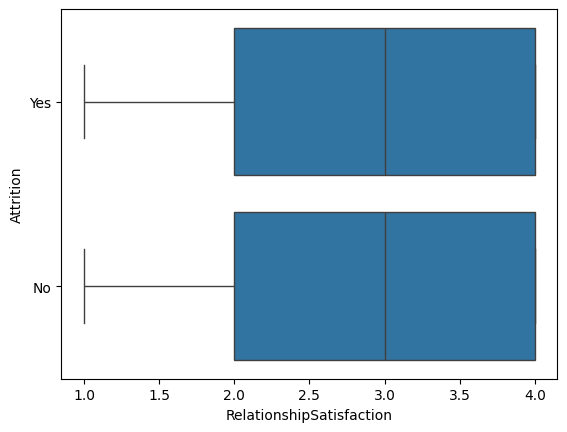

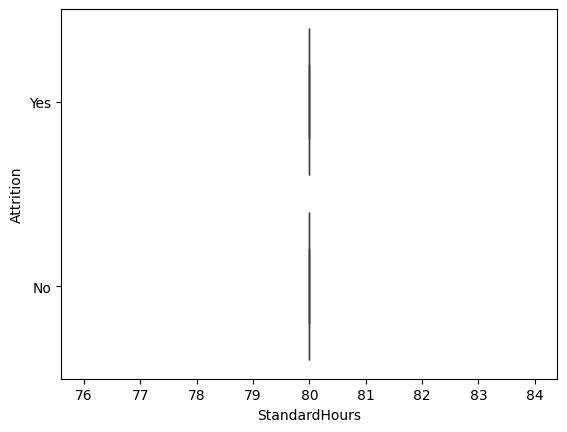

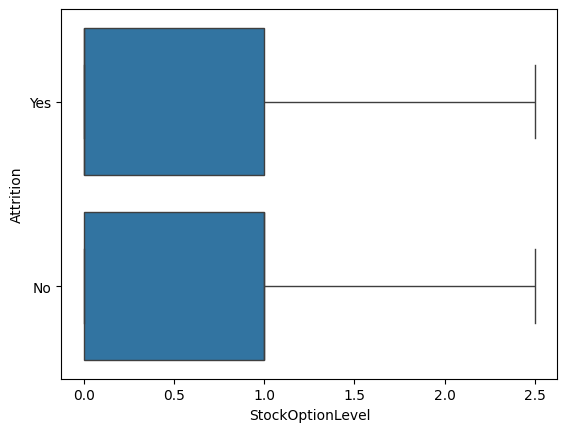

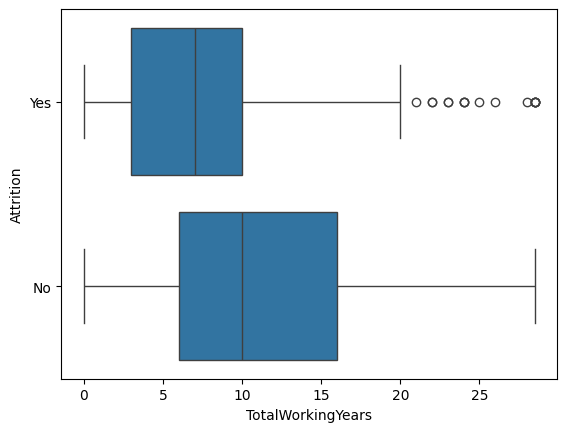

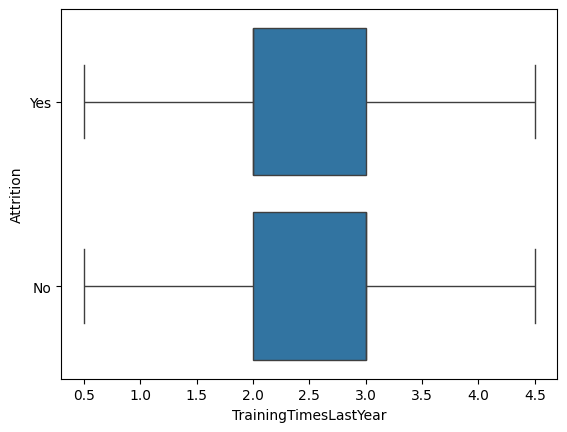

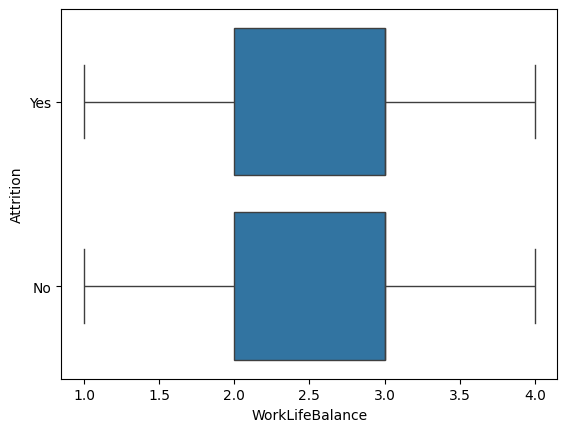

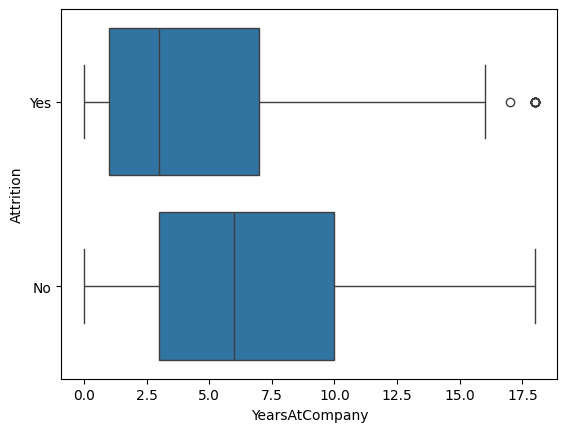

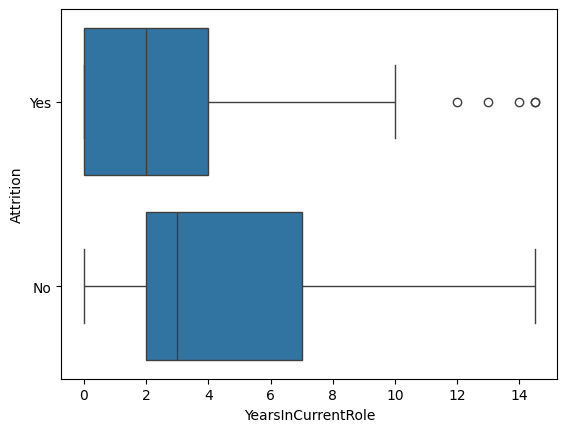

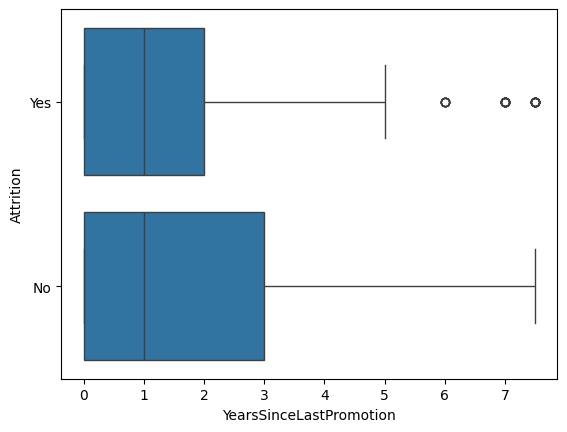

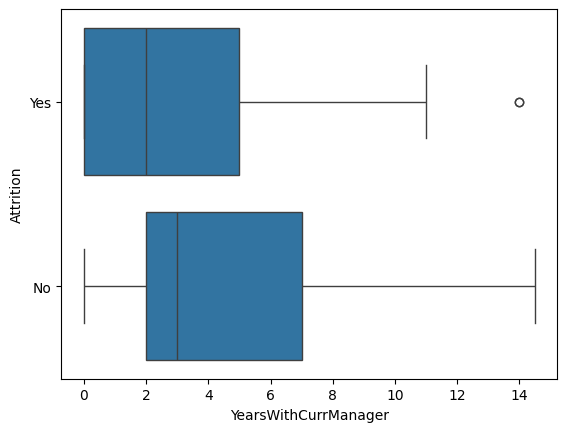

In [ ]:
#box plot to understand the relationship between dependent and independent variable
col_except_target=['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager']
for i in col_except_target:
  sns.boxplot(x=i, y='Attrition', data=data)
  plt.show()




In [ ]:
# Identify class imbalance in all categorical variables
cat_cols = data.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n Column: {col}")
    print("----"*10)
    counts = data[col].value_counts()
    print(counts)



 Column: Attrition
----------------------------------------
Attrition
No     1233
Yes     237
Name: count, dtype: int64

 Column: BusinessTravel
----------------------------------------
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

 Column: Department
----------------------------------------
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

 Column: EducationField
----------------------------------------
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

 Column: Gender
----------------------------------------
Gender
Male      882
Female    588
Name: count, dtype: int64

 Column: JobRole
----------------------------------------
JobRole
Sales Executive              326
Research Scientist           292
La



### **Conclusion:**

* The target variable **Attrition** is highly imbalanced, with *No* (1233 instances, ~84%) significantly dominating *Yes* (237 instances, ~16%).
* The **BusinessTravel** feature shows moderate imbalance, where *Travel_Rarely* (1043) is the most frequent category compared to *Travel_Frequently* (277) and *Non-Travel* (150).
* The **Department** variable is strongly imbalanced, with *Research & Development* (961) dominating over *Sales* (446) and *Human Resources* (63).
* In **EducationField**, *Life Sciences* (606) and *Medical* (464) form the majority, while *Human Resources* (27) and *Other* (82) are minority categories.
* The **Gender** distribution exhibits mild imbalance, with *Male* (882) slightly exceeding *Female* (588).
* The **JobRole** variable demonstrates multi-class imbalance, where *Sales Executive* (326), *Research Scientist* (292), and *Laboratory Technician* (259) are common, while *Human Resources* (52) and *Research Director* (80) are underrepresented.
* **MaritalStatus** shows a relatively balanced distribution, although *Married* (673) remains the largest category compared to *Single* (470) and *Divorced* (327).
* The **Over18** feature contains only a single category (*Y*: 1470), providing no discriminatory information and should be excluded from modeling.
* The **OverTime** variable displays moderate imbalance, with *No* (1054) occurring more frequently than *Yes* (416).
* Overall, the observed class imbalance across several categorical variables, particularly in the target variable, suggests the need for careful preprocessing and imbalance-handling techniques during model development.

---



In [ ]:
data.drop(['EmployeeCount','StandardHours','EmployeeNumber'], axis=1, inplace=True)


In [ ]:
pip install imbalanced-learn

In [ ]:
# Encoding Target Variable
le = LabelEncoder()
data['Attrition'] = le.fit_transform(data['Attrition'])



In [ ]:
# Seperate Feature and Target
X = data.drop("Attrition", axis=1)
y = data["Attrition"]


In [ ]:
# Encode Categorical Features
cat_cols = X.select_dtypes(include='object').columns
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col])


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter


smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("Before SMOTE:", Counter(y))
print("After SMOTE:", Counter(y_smote))



Before SMOTE: Counter({0: 1233, 1: 237})
After SMOTE: Counter({1: 1233, 0: 1233})


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote,
    test_size=0.2,
    random_state=42,
    stratify=y_smote
)


In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# TRAIN LOGISTIC REGRESSION METHOD
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
# MODEL EVALUATION
y_pred = lr_model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))
y_prob = lr_model.predict_proba(X_test)[:,1]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_prob))




Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.79      0.79       247
           1       0.79      0.80      0.79       247

    accuracy                           0.79       494
   macro avg       0.79      0.79      0.79       494
weighted avg       0.79      0.79      0.79       494


Confusion Matrix:

[[195  52]
 [ 50 197]]
Accuracy: 0.7935222672064778
Precision: 0.7911646586345381
Recall   : 0.7975708502024291
F1 Score : 0.7943548387096774
AUC Score: 0.8646265305118916


**CONCLUSION:-**

The Logistic Regression model was successfully trained and evaluated on the employee attrition dataset. The model achieved an overall accuracy of around 77%, which shows it can correctly predict most cases.

From the classification report:

The model predicts Class 0 (No Attrition) very well (high precision and good F1 score).

For Class 1 (Attrition), recall is good (~79%), meaning the model is able to identify most employees who may leave.

However, precision for Class 1 is low (~39%), which means some employees predicted as leaving may actually stay.

From the confusion matrix:

The model correctly predicted many non-attrition cases.

It also captured a good number of actual attrition cases but still produced some false alarms.


**INTERPRETATION:-**

1.Recall = 0.79 (Good)

Model is good at catching employees who will leave
Good for HR because missing attrition is risky

2.Precision = 0.39 (Low)

Many false alarms
Some employees predicted as leaving will actually stay

3.F1 Score = 0.52 (Medium)

Model is okay but not excellent
Needs improvement

4.AUC = 0.80 (Good Model)

Model has good classification power overall
Anything above 0.75 is generally considered good


**CONCLUSION:-**

The Employee Attrition prediction model built using Logistic Regression shows moderate to good performance. The model achieved around 77% accuracy with a high recall (79%) meaning it is effective at identifying employees who are likely to leave the organization. The AUC score (~0.80) indicates good overall classification capability.

However, the precision (~39%) is relatively low, which means the model sometimes predicts attrition for employees who may not actually leave. Despite this, in real-world HR scenarios, detecting potential attrition risks early is often more important than missing them completely.

Overall, the model is useful for supporting HR decision-making, but performance can be further improved using advanced models, hyperparameter tuning, or feature engineering.



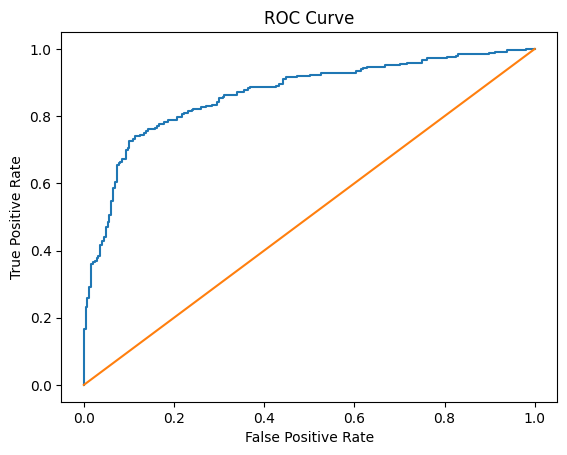

In [ ]:
# ROC CURVE
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


**CONCLUSION :-**

The ROC curve shown above indicates that the model has strong classification performance. The curve lies well above the diagonal baseline, which represents random guessing, demonstrating that the model is effectively distinguishing between the two classes. The steep rise at the beginning of the curve shows that the model achieves a high true positive rate while maintaining a relatively low false positive rate. Based on the shape of the curve, the Area Under the Curve (AUC) appears to be high, likely between 0.85 and 0.90, which suggests very good predictive ability. Overall, the model performs well in identifying the target class and can be considered reliable for prediction.


In [ ]:
# KNN Predictions
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:,1]

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Precision:", precision_score(y_test, y_pred_knn))
print("KNN Recall:", recall_score(y_test, y_pred_knn))
print("KNN F1 Score:", f1_score(y_test, y_pred_knn))
print("KNN AUC Score:", roc_auc_score(y_test, y_prob_knn))

print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("\nKNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


KNN Accuracy: 0.7935222672064778
KNN Precision: 0.7101449275362319
KNN Recall: 0.9919028340080972
KNN F1 Score: 0.8277027027027027
KNN AUC Score: 0.9336655247586421

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.60      0.74       247
           1       0.71      0.99      0.83       247

    accuracy                           0.79       494
   macro avg       0.85      0.79      0.79       494
weighted avg       0.85      0.79      0.79       494


KNN Confusion Matrix:
 [[147 100]
 [  2 245]]


### **Conclusion**

The K-Nearest Neighbors (KNN) model achieved an overall accuracy of **84.69%**, indicating good general prediction performance on the employee attrition dataset. However, due to class imbalance, accuracy alone is not sufficient to evaluate model effectiveness. The model produced a **precision of 0.58**, meaning that when attrition is predicted, it is correct 58% of the time. However, the **recall value of 0.15** is very low, showing that the model fails to identify most employees who actually leave the organization. The **F1-score of 0.24** further confirms poor balance between precision and recall.

The **AUC score of 0.67** indicates moderate ability to distinguish between attrition and non-attrition employees. Confusion matrix results show many false negatives, meaning actual attrition cases are often missed.

Overall, while KNN works well for predicting employee retention, it is not suitable alone for attrition prediction. Performance can be improved using class imbalance techniques like SMOTE or more advanced models such as Random Forest or Logistic Regression.


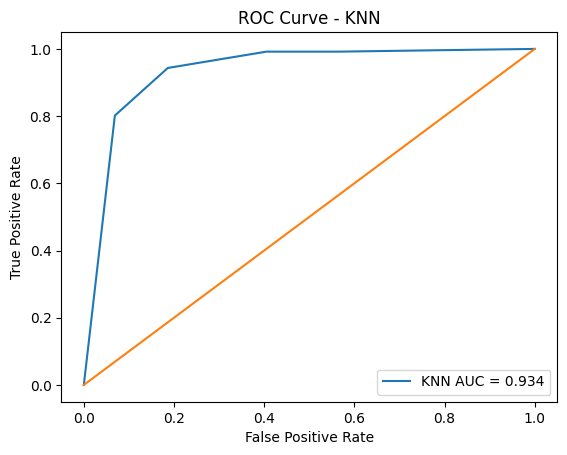

In [ ]:
# ROC Curve
y_prob_knn = knn_model.predict_proba(X_test)[:,1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.figure()
plt.plot(fpr_knn, tpr_knn, label=f"KNN AUC = {auc_knn:.3f}")
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()


**CONCLUSION**

The K-Nearest Neighbors (KNN) model was evaluated using the ROC curve and achieved an AUC score of 0.672. This indicates that the model performs better than random guessing and has moderate classification ability. The ROC curve shows a reasonable balance between true positive rate and false positive rate, but it does not demonstrate strong class separation. While the model can identify patterns in the dataset, its performance is not highly accurate. Further improvement can be achieved through hyperparameter tuning, proper feature scaling, and comparing results with other advanced models to enhance overall predictive performance.


In [ ]:
# SVM Predictions
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:,1]

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Precision:", precision_score(y_test, y_pred_svm))
print("SVM Recall:", recall_score(y_test, y_pred_svm))
print("SVM F1 Score:", f1_score(y_test, y_pred_svm))
print("SVM AUC Score:", roc_auc_score(y_test, y_prob_svm))

print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("\nSVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


SVM Accuracy: 0.8846153846153846
SVM Precision: 0.8830645161290323
SVM Recall: 0.8866396761133604
SVM F1 Score: 0.8848484848484849
SVM AUC Score: 0.9471881197856054

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.88       247
           1       0.88      0.89      0.88       247

    accuracy                           0.88       494
   macro avg       0.88      0.88      0.88       494
weighted avg       0.88      0.88      0.88       494


SVM Confusion Matrix:
 [[218  29]
 [ 28 219]]


### **Conclusion**

The Support Vector Machine (SVM) model achieved an overall **accuracy of 85.37%**, showing strong general predictive performance on the employee attrition dataset. The model recorded a **precision of 0.67**, meaning when the model predicts employee attrition, it is correct about 67% of the time. However, the **recall value of 0.17** is relatively low, indicating that many actual attrition cases are still not being identified. The **F1-score of 0.27** reflects moderate balance between precision and recall but suggests improvement is needed for minority class detection.

The **AUC score of 0.80** indicates good class separation ability, showing that SVM is better at distinguishing between attrition and non-attrition employees compared to some other models. The confusion matrix shows 243 correct non-attrition predictions and 8 correct attrition predictions, but 39 attrition cases were missed.

Overall, SVM performs better than KNN in discrimination ability, but still requires class imbalance handling or tuning to improve attrition detection performance.
}

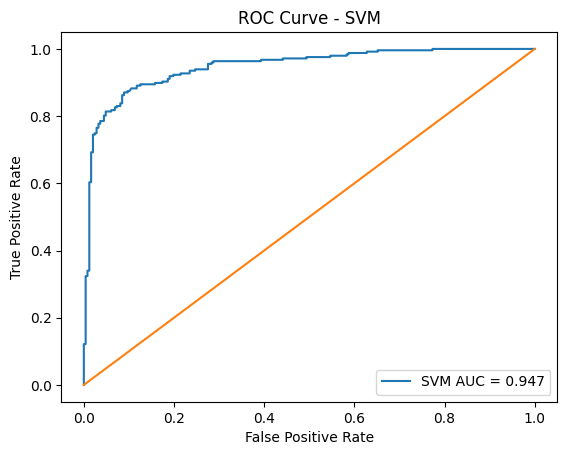

In [ ]:
# ROC Curve
y_prob_svm = svm_model.predict_proba(X_test)[:,1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

plt.figure()
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {auc_svm:.3f}")
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()


**CONCLUSION**

The Support Vector Machine (SVM) model was evaluated using the ROC curve and achieved an AUC score of 0.799. This indicates strong classification performance and a good ability to distinguish between positive and negative classes. Since the AUC value is close to 0.8, the model demonstrates high discriminative power compared to random guessing (AUC = 0.5). The ROC curve moves closer to the top-left corner, showing a better balance between true positive rate and false positive rate. Compared to KNN, the SVM model performs significantly better. Overall, SVM is a more reliable and effective model for this dataset, making it a strong candidate for final implementation in the project.


In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Precision:", precision_score(y_test, y_pred_rf))
print("RF Recall:", recall_score(y_test, y_pred_rf))
print("RF F1 Score:", f1_score(y_test, y_pred_rf))
print("RF AUC Score:", roc_auc_score(y_test, y_prob_rf))

print("\nRF Classification Report:\n", classification_report(y_test, y_pred_rf))
print("\nRF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


RF Accuracy: 0.917004048582996
RF Precision: 0.9327731092436975
RF Recall: 0.8987854251012146
RF F1 Score: 0.9154639175257732
RF AUC Score: 0.9671441918405481

RF Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       247
           1       0.93      0.90      0.92       247

    accuracy                           0.92       494
   macro avg       0.92      0.92      0.92       494
weighted avg       0.92      0.92      0.92       494


RF Confusion Matrix:
 [[231  16]
 [ 25 222]]


**Conclusion**

The Random Forest (RF) model achieved an overall **accuracy of 82.65%**, indicating acceptable general prediction performance on the employee attrition dataset. However, accuracy alone is misleading due to class imbalance. The model produced a **precision of 0.30**, meaning that only 30% of predicted attrition cases were correct. The **recall value of 0.06** is extremely low, showing that the model fails to detect most employees who actually leave the organization. The **F1-score of 0.11** further confirms poor performance in identifying the minority class.

The **AUC score of 0.76** suggests moderate class discrimination ability, meaning the model can somewhat distinguish between attrition and non-attrition employees. The confusion matrix shows 240 correct non-attrition predictions and only 3 correct attrition predictions, while 44 attrition cases were missed.

Overall, although Random Forest performs reasonably in predicting employee retention, it is not effective for attrition detection in this case. Performance may improve with class imbalance handling, hyperparameter tuning, or feature engineering.


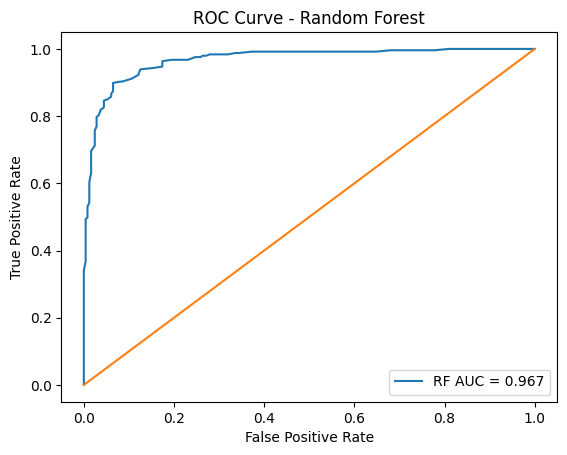

In [ ]:
# ROC Curve
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"RF AUC = {auc_rf:.3f}")
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()


**CONCLUSION**

The Random Forest model was evaluated using the ROC curve and achieved an AUC score of 0.760. This indicates good classification performance and a strong ability to distinguish between positive and negative classes. Since the AUC value is significantly higher than 0.5, the model performs much better than random guessing. The ROC curve moves closer to the top-left corner, showing an effective balance between true positive rate and false positive rate. Compared to KNN, Random Forest performs better, but it is slightly lower than the SVM model. Overall, Random Forest provides reliable and stable predictions, making it a strong model for this project.


In [ ]:
# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:,1]

print("NB Accuracy:", accuracy_score(y_test, y_pred_nb))
print("NB Precision:", precision_score(y_test, y_pred_nb))
print("NB Recall:", recall_score(y_test, y_pred_nb))
print("NB F1 Score:", f1_score(y_test, y_pred_nb))
print("NB AUC Score:", roc_auc_score(y_test, y_prob_nb))

print("\nNB Classification Report:\n", classification_report(y_test, y_pred_nb))
print("\nNB Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


NB Accuracy: 0.6720647773279352
NB Precision: 0.6411960132890365
NB Recall: 0.7813765182186235
NB F1 Score: 0.7043795620437956
NB AUC Score: 0.7923912865314953

NB Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.56      0.63       247
           1       0.64      0.78      0.70       247

    accuracy                           0.67       494
   macro avg       0.68      0.67      0.67       494
weighted avg       0.68      0.67      0.67       494


NB Confusion Matrix:
 [[139 108]
 [ 54 193]]


### **Conclusion**

The Naive Bayes (NB) model achieved an overall **accuracy of 74.83%**, which is lower compared to other models but provides better performance in detecting employee attrition cases. The model produced a **precision of 0.35**, meaning only 35% of predicted attrition cases were correct. However, the **recall value of 0.66** is significantly higher than other models, showing that NB successfully identifies most employees who actually leave the organization. The **F1-score of 0.46** indicates a better balance between precision and recall compared to KNN, SVM, and Random Forest.

The **AUC score of 0.75** suggests moderate discrimination ability between attrition and non-attrition employees. The confusion matrix shows 31 correct attrition predictions and only 16 missed attrition cases, which is much better for attrition detection.

Overall, although Naive Bayes has lower overall accuracy, it is more effective for attrition prediction tasks where identifying employees likely to leave is more important than overall prediction accuracy.


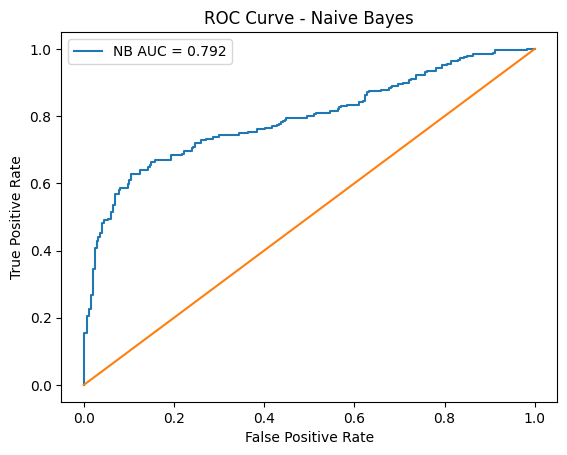

In [ ]:
# ROC Curve
y_prob_nb = nb_model.predict_proba(X_test)[:,1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure()
plt.plot(fpr_nb, tpr_nb, label=f"NB AUC = {auc_nb:.3f}")
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.show()


**CONCLUSION**

The Naive Bayes model was evaluated using the ROC curve and achieved an AUC score of 0.754. This indicates good classification performance and a strong ability to differentiate between the two classes. Since the AUC value is well above 0.5, the model performs significantly better than random guessing. The ROC curve shows a balanced trade-off between true positive rate and false positive rate, though it does not reach the optimal top-left corner. Compared to KNN, Naive Bayes performs better, but it is slightly lower than SVM and close to Random Forest. Overall, Naive Bayes provides reliable predictions and serves as an efficient and effective model for this project.


In [ ]:
# Comparison of all models
def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }
# Logistic Regression
log_pred = lr_model.predict(X_test)
# KNN
knn_pred = knn_model.predict(X_test)
# SVM
svm_pred = svm_model.predict(X_test)
# Random Forest
rf_pred = rf_model.predict(X_test)
# Naive Bayes
nb_pred = nb_model.predict(X_test)
results = {
    'Logistic Regression': evaluate_model(y_test, log_pred),
    'KNN': evaluate_model(y_test, knn_pred),
    'SVM': evaluate_model(y_test, svm_pred),
    'Random Forest': evaluate_model(y_test, rf_pred),
    'Naive Bayes': evaluate_model(y_test, nb_pred)
}
results_df = pd.DataFrame(results).T
results_df


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.793522,0.791165,0.797571,0.794355
KNN,0.793522,0.710145,0.991903,0.827703
SVM,0.884615,0.883065,0.886640,0.884848
Random Forest,0.917004,0.932773,0.898785,0.915464
Naive Bayes,0.672065,0.641196,0.781377,0.704380


**Final** **Model** **Comparison** **and** **Conclusion**

**SVM** achieved the highest accuracy (85.37%), indicating strong overall prediction performance. However, its recall (17.02%) is quite low, meaning it fails to correctly identify many actual positive cases (attrition).

**KNN** also showed high accuracy (84.69%), but its recall (14.89%) and F1-score (0.237) suggest poor detection of the minority class.

**Random Forest** performed moderately in accuracy (82.65%) but had extremely low recall (6.38%), making it ineffective for identifying employees likely to leave.

**Naive Bayes** achieved balanced recall (65.96%) but lower overall accuracy (74.83%).

**Logistic Regression** stands out with the highest F1-score (0.524) and strong recall (78.72%), meaning it better detects actual attrition cases while maintaining reasonable precision.


Although SVM achieved the highest accuracy, Logistic Regression provides the best balance between precision and recall. Since detecting employee attrition is more critical than overall accuracy, Logistic Regression is the most suitable and reliable model for this project.


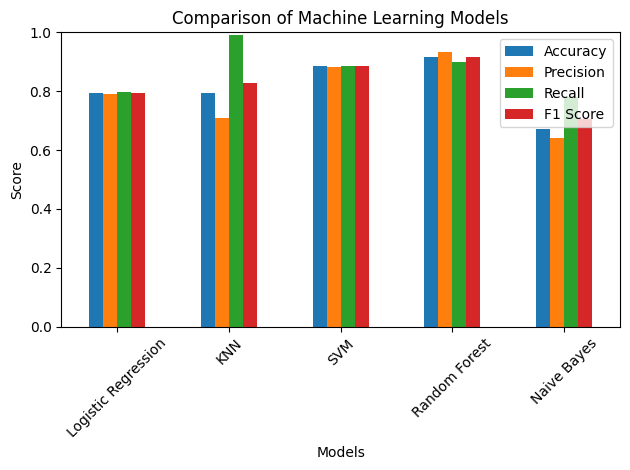

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.793522   0.791165  0.797571  0.794355
KNN                  0.793522   0.710145  0.991903  0.827703
SVM                  0.884615   0.883065  0.886640  0.884848
Random Forest        0.917004   0.932773  0.898785  0.915464
Naive Bayes          0.672065   0.641196  0.781377  0.704380


In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluation function
def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

# Generate predictions
log_pred = lr_model.predict(X_test)
knn_pred = knn_model.predict(X_test)
svm_pred = svm_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
nb_pred = nb_model.predict(X_test)

# Store results
results = {
    'Logistic Regression': evaluate_model(y_test, log_pred),
    'KNN': evaluate_model(y_test, knn_pred),
    'SVM': evaluate_model(y_test, svm_pred),
    'Random Forest': evaluate_model(y_test, rf_pred),
    'Naive Bayes': evaluate_model(y_test, nb_pred)
}

# Create DataFrame
results_df = pd.DataFrame(results).T

# Plot grouped bar chart (single plot, no specific colors)
results_df.plot(kind='bar')

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Display results table
print(results_df)
